### `Powershell Commands`

In [ ]:
.\test_lab\testlab\Scripts\activate
& "$env:LOCALAPPDATA\Programs\nu\bin\nu.exe"

aria2c -c -x9 -s9 -d "downloads" "URL"
7z x "C:\Users\ritwi\Downloads\Foxit_PDF_Editor_Pro_v2025.1.0.27937.rar"


### `nvidia-smi`

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Compute device active: {device}")

### `yt-download`

In [ ]:
import os
import sys
import yt_dlp

# Constants for ease of use
video = 'video'
music = 'music'

def download_media(query_or_url, mode):
    """
    Downloads media from YouTube using yt-dlp based on mode.
    """
    # Ensure the directory exists
    os.makedirs('./downloads', exist_ok=True)

    if mode == music:
        print("Mode: MUSIC (Best Quality Audio 320kbps)")
        ydl_opts = {
        'format': 'bestaudio/best',
        'outtmpl': './downloads/%(title)s.%(ext)s',
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
            'preferredquality': '320',
        }, {
            'key': 'EmbedThumbnail',
        }, {
            'key': 'FFmpegMetadata',
        }],
        'logger': MyLogger(),
        'progress_hooks': [my_hook],
        'writethumbnail': True,
        'remote_components': 'ejs:github',
        }
    elif mode == video:
        print("Mode: VIDEO (Best Quality Video + Audio)")
        # 'bestvideo+bestaudio/best' ensures no compromise on quality
        # Video and Audio will be downloaded separately at maximum quality and merged
        ydl_opts = {
        'format': 'bestvideo+bestaudio/best',
        'outtmpl': './downloads/%(title)s.%(ext)s',
        'postprocessors': [{
            'key': 'EmbedThumbnail',
        }, {
            'key': 'FFmpegMetadata',
        }],
        'logger': MyLogger(),
        'progress_hooks': [my_hook],
        'writethumbnail': True,
        # mkv safely merges any two formats without lossy re-encoding
        'merge_output_format': 'mkv',
        'remote_components': 'ejs:github', 
        }
    else:
        print(f"Error: Invalid mode '{mode}'. Set it to music or video.")
        return

    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            if not query_or_url.startswith(('http://', 'https://')):
                print(f"Searching for: {query_or_url}")
                ydl.download([f"ytsearch1:{query_or_url}"])
            else:
                print(f"Downloading from URL: {query_or_url}")
                ydl.download([query_or_url])
    except Exception as e:
        print(f"Error: {e}")

class MyLogger(object):
    def debug(self, msg):
        pass

    def warning(self, msg):
        print(f"Warning: {msg}")

    def error(self, msg):
        print(f"Error: {msg}")

def my_hook(d):
    if d['status'] == 'finished':
        print(f"\nDone downloading, now processing...")
    if d['status'] == 'downloading':
        sys.stdout.write(f"\rDownloading: {d.get('_percent_str', 'N/A')}   ")
        sys.stdout.flush()

def main(url, mode):
    """
    Trigger the download for the given URL and mode.
    """
    print("--- Master YouTube Downloader ---")
    if url and url != "YOUR_URL_HERE":
        download_media(url, mode)
    else:
        print("No valid URL provided. Please replace 'YOUR_URL_HERE' with a real URL.")

if __name__ == "__main__":
    # ==========================================
    # MANUAL EXECUTION
    # Drop the URL and mode here. 
    # Example: main("https://www.youtube.com/watch?v=...", video)
    # Example: main("https://www.youtube.com/watch?v=...", music)
    # ==========================================
    
    main("YOUR_URL_HERE", video)


### `GARDEN`

<iframe width="560" height="315" src="https://youtu.be/gHcn4wBygDY" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

# <span style="background-color:green; color:black">LaTeX</span>



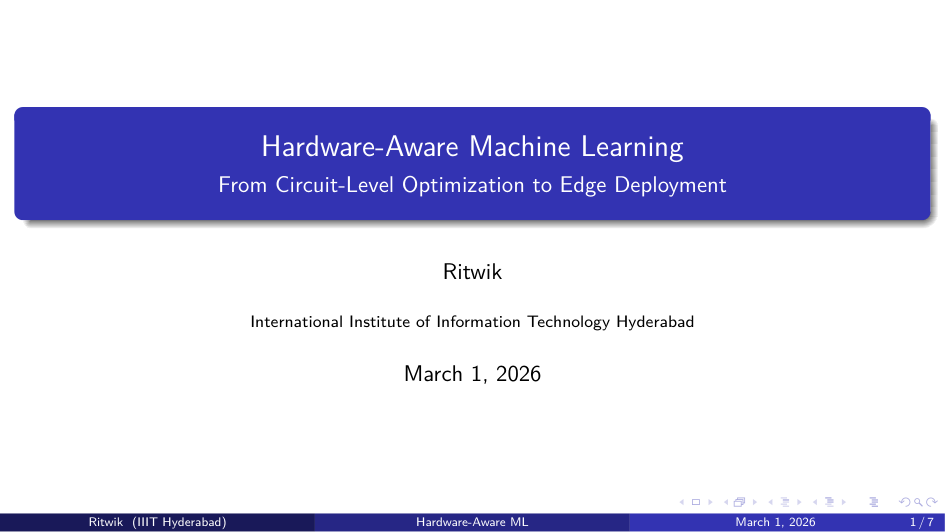

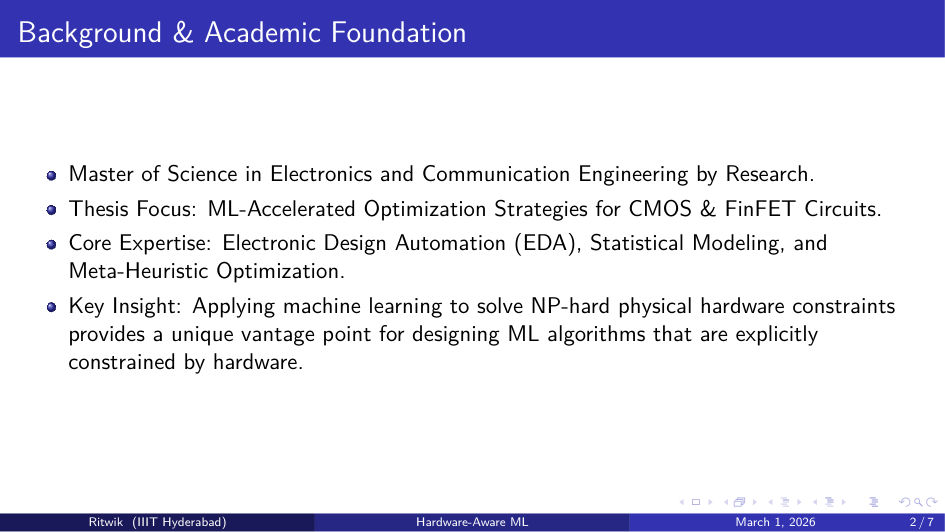

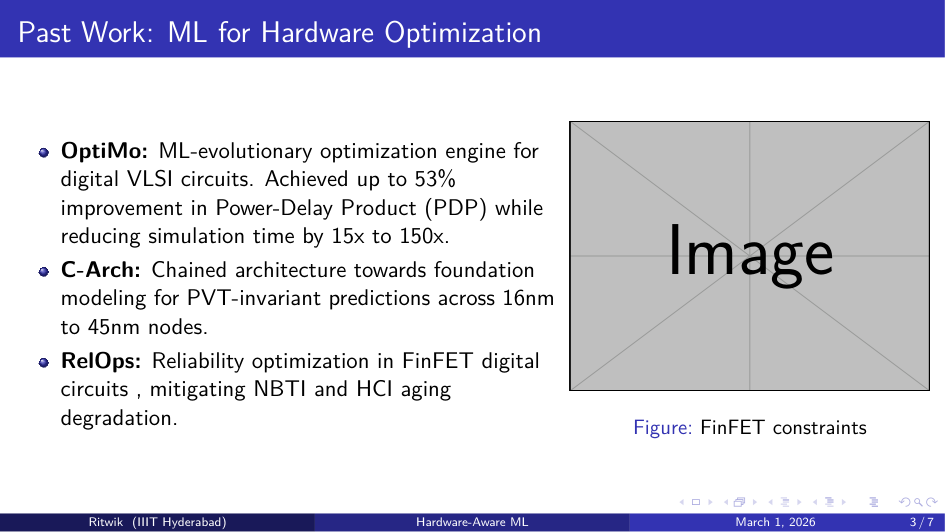

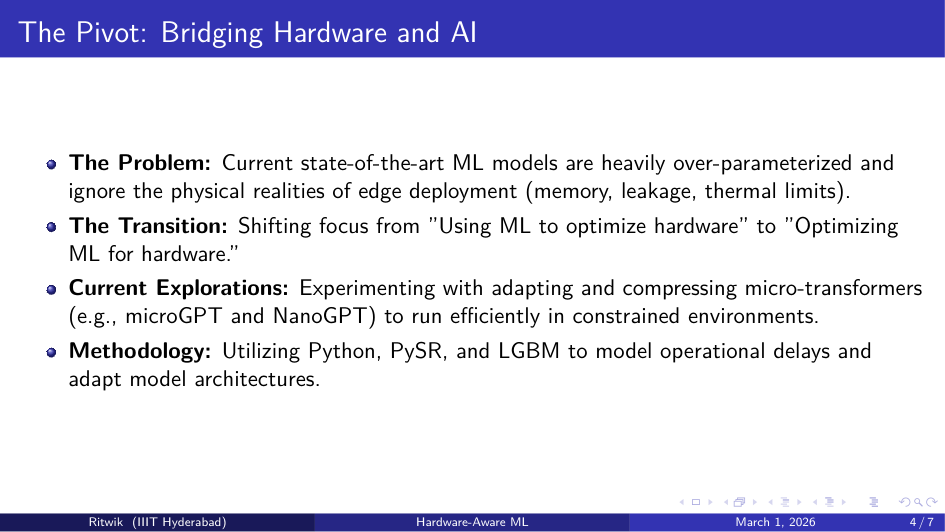

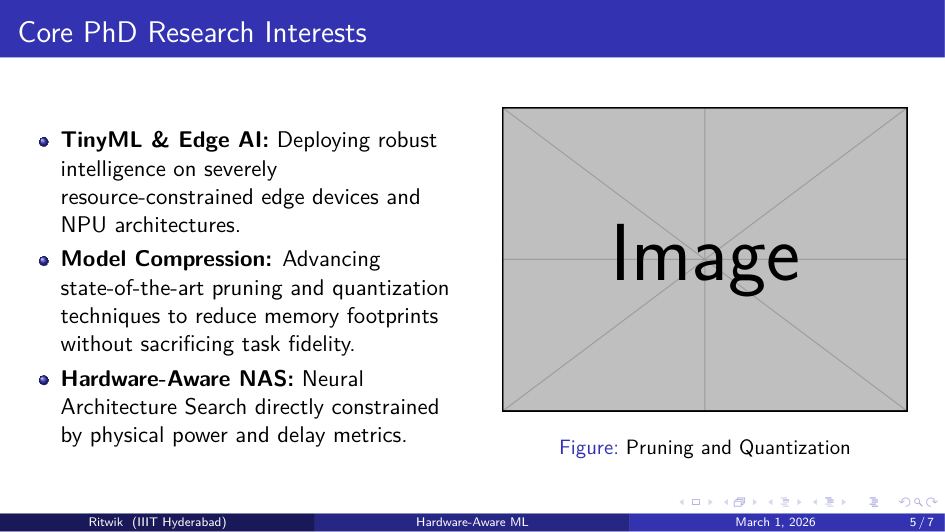

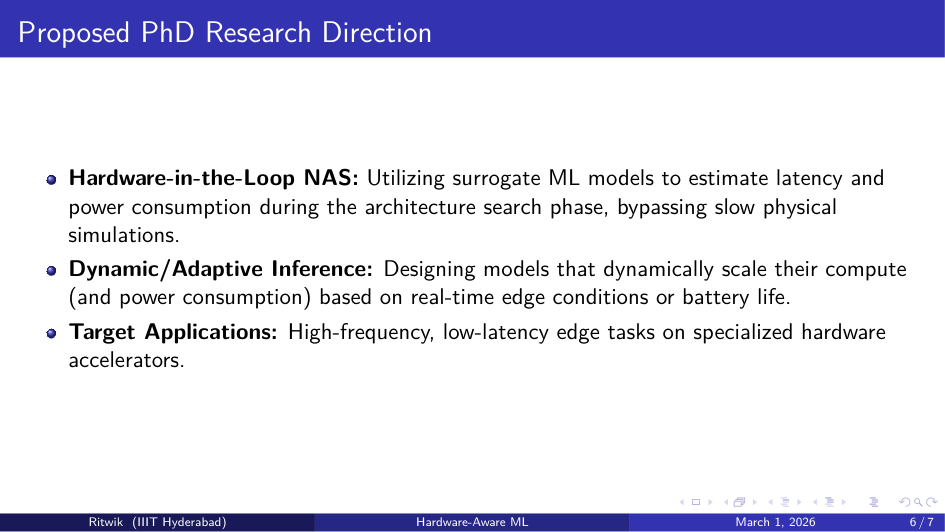

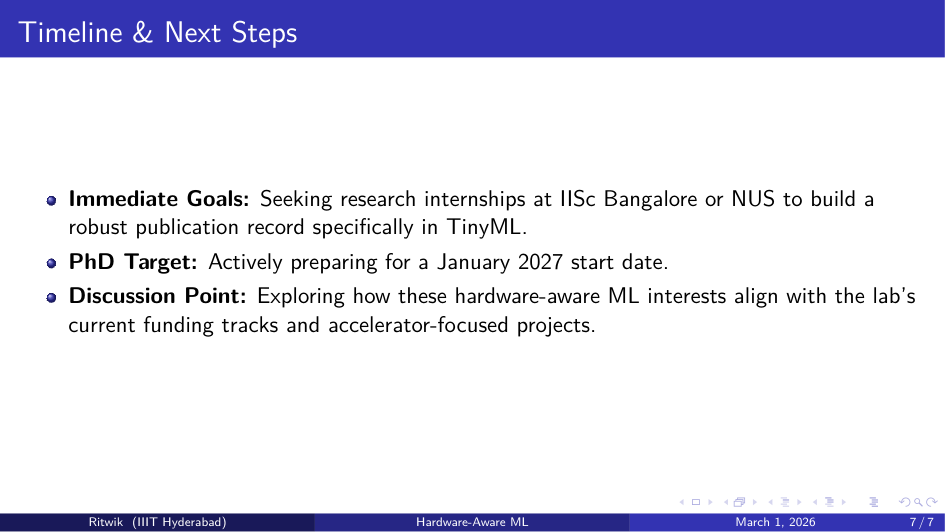

In [4]:
import fitz # PyMuPDF
from IPython.display import display
from PIL import Image

# Open the PDF we copied into the MY_ARMY folder
doc = fitz.open('LaTeX_Presentation/presentation_rectified.pdf')

# Render each slide and display it
for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    
    # Get a high-resolution pixmap of the page
    pix = page.get_pixmap(dpi=150)
    
    # Convert it to a PIL Image so Jupyter knows how to display it natively
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    
    # Display the image inline
    display(img)


### `.tex`

In [ ]:
\documentclass[aspectratio=169]{beamer}
\usetheme{Madrid}
\usecolortheme{default}
\usepackage{graphicx}

\title[Hardware-Aware ML]{Hardware-Aware Machine Learning}
\subtitle{From Circuit-Level Optimization to Edge Deployment}
\author{Ritwik}
\institute[IIIT Hyderabad]{International Institute of Information Technology Hyderabad }
\date{\today}

\begin{document}

\begin{frame} \relax
    \titlepage
\end{frame}

\begin{frame} \relax
    \frametitle{Background \& Academic Foundation} \relax
    \begin{itemize} \relax
        \item \relax {Master of Science in Electronics and Communication Engineering by Research.}
        \item \relax {Thesis Focus: ML-Accelerated Optimization Strategies for CMOS \& FinFET Circuits.}
        \item \relax {Core Expertise: Electronic Design Automation (EDA), Statistical Modeling, and Meta-Heuristic Optimization.}
        \item \relax {Key Insight: Applying machine learning to solve NP-hard physical hardware constraints provides a unique vantage point for designing ML algorithms that are explicitly constrained by hardware.}
    \end{itemize}
\end{frame}

\begin{frame} \relax
    \frametitle{Past Work: ML for Hardware Optimization} \relax
    \begin{columns}
        \begin{column}{0.6\textwidth}
            \begin{itemize} \relax
                \item \relax {\textbf{OptiMo:} ML-evolutionary optimization engine for digital VLSI circuits. Achieved up to 53\% improvement in Power-Delay Product (PDP)  while reducing simulation time by 15x to 150x.}
                \item \relax {\textbf{C-Arch:} Chained architecture towards foundation modeling  for PVT-invariant predictions across 16nm to 45nm nodes.}
                \item \relax {\textbf{RelOps:} Reliability optimization in FinFET digital circuits , mitigating NBTI and HCI aging degradation.}
            \end{itemize}
        \end{column}
        \begin{column}{0.4\textwidth}
            \begin{figure}
                \centering
                % Insert image here: A diagram of a CMOS FinFET transistor architecture
                \includegraphics[width=\textwidth]{example-image}
                \caption{FinFET constraints}
            \end{figure}
        \end{column}
    \end{columns}
\end{frame}

\begin{frame} \relax
    \frametitle{The Pivot: Bridging Hardware and AI} \relax
    \begin{itemize} \relax
        \item \relax {\textbf{The Problem:} Current state-of-the-art ML models are heavily over-parameterized and ignore the physical realities of edge deployment (memory, leakage, thermal limits).}
        \item \relax {\textbf{The Transition:} Shifting focus from "Using ML to optimize hardware" to "Optimizing ML for hardware."}
        \item \relax {\textbf{Current Explorations:} Experimenting with adapting and compressing micro-transformers (e.g., microGPT and NanoGPT) to run efficiently in constrained environments.}
        \item \relax {\textbf{Methodology:} Utilizing Python, PySR, and LGBM to model operational delays and adapt model architectures.}
    \end{itemize}
\end{frame}

\begin{frame} \relax
    \frametitle{Core PhD Research Interests} \relax
    \begin{columns}
        \begin{column}{0.5\textwidth}
            \begin{itemize} \relax
                \item \relax {\textbf{TinyML \& Edge AI:} Deploying robust intelligence on severely resource-constrained edge devices and NPU architectures.}
                \item \relax {\textbf{Model Compression:} Advancing state-of-the-art pruning and quantization techniques to reduce memory footprints without sacrificing task fidelity.}
                \item \relax {\textbf{Hardware-Aware NAS:} Neural Architecture Search directly constrained by physical power and delay metrics.}
            \end{itemize}
        \end{column}
        \begin{column}{0.5\textwidth}
            \begin{figure}
                \centering
                % Insert image here: A diagram of neural network pruning and quantization
                \includegraphics[width=0.9\textwidth]{example-image}
                \caption{Pruning and Quantization}
            \end{figure}
        \end{column}
    \end{columns}
\end{frame}

\begin{frame} \relax
    \frametitle{Proposed PhD Research Direction} \relax
    \begin{itemize} \relax
        \item \relax {\textbf{Hardware-in-the-Loop NAS:} Utilizing surrogate ML models to estimate latency and power consumption during the architecture search phase, bypassing slow physical simulations.}
        \item \relax {\textbf{Dynamic/Adaptive Inference:} Designing models that dynamically scale their compute (and power consumption) based on real-time edge conditions or battery life.}
        \item \relax {\textbf{Target Applications:} High-frequency, low-latency edge tasks on specialized hardware accelerators.}
    \end{itemize}
\end{frame}

\begin{frame} \relax
    \frametitle{Timeline \& Next Steps} \relax
    \begin{itemize} \relax
        \item \relax {\textbf{Immediate Goals:} Seeking research internships at IISc Bangalore or NUS to build a robust publication record specifically in TinyML.}
        \item \relax {\textbf{PhD Target:} Actively preparing for a January 2027 start date.}
        \item \relax {\textbf{Discussion Point:} Exploring how these hardware-aware ML interests align with the lab's current funding tracks and accelerator-focused projects.}
    \end{itemize}
\end{frame}

\end{document}

In [ ]:
"""
######################## PDF COMPILER ########################
"""

import os
import urllib.request
import zipfile
import subprocess
import sys

def download_and_extract_tectonic():
    tectonic_exe = "tectonic.exe"
    zip_filename = "tectonic.zip"
    url = "https://github.com/tectonic-typesetting/tectonic/releases/download/tectonic%400.15.0/tectonic-0.15.0-x86_64-pc-windows-msvc.zip"

    if os.path.exists(tectonic_exe):
        print("Tectonic is already downloaded.")
        return tectonic_exe

    print("Downloading Tectonic standalone LaTeX compiler (this will keep your system clean)...")
    try:
        urllib.request.urlretrieve(url, zip_filename)
        print("Download complete. Extracting...")
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall()
        os.remove(zip_filename)
        print("Extraction complete.")
        return tectonic_exe
    except Exception as e:
        print(f"Error downloading or extracting Tectonic: {e}")
        return None

def compile_latex(tex_file):
    tectonic_exe = download_and_extract_tectonic()
    if not tectonic_exe:
        print("Compilation aborted due to missing compiler.")
        return

    print(f"Compiling {tex_file}...")
    try:
        # Tectonic automatically downloads required LaTeX packages on the fly
        result = subprocess.run([tectonic_exe, tex_file], capture_output=True, text=True)
        if result.returncode == 0:
            pdf_file = tex_file.replace(".tex", ".pdf")
            print(f"Successfully compiled! PDF saved as {pdf_file}")
            # Try to open the PDF
            try:
                os.startfile(pdf_file)
            except Exception:
                print(f"Could not automatically open {pdf_file}. You can open it manually.")
        else:
            print("Compilation failed with errors:")
            print(result.stderr)
            print(result.stdout)
    except Exception as e:
        print(f"Error during compilation string execution: {e}")

if __name__ == "__main__":
    if len(sys.argv) > 1:
        tex_file = sys.argv[1]
    else:
        tex_file = "presentation_rectified.tex"
        
    compile_latex(tex_file)


In [ ]:
"""
########################## PDF to PPTX ########################## 
"""

import os
import sys
from pdf2image import convert_from_path
from pptx import Presentation
from pptx.util import Inches

def pdf_to_pptx(pdf_path, pptx_path):
    print(f"Converting PDF '{pdf_path}' to Images...")
    
    try:
        # Note: on Windows, poppler is required for pdf2image.
        # But since we are generating slides, let's try a fallback: PyMuPDF (fitz) is more self-contained.
        import fitz  # PyMuPDF
        
        doc = fitz.open(pdf_path)
        prs = Presentation()
        
        # Set slide width and height to 16:9 ratio (standard widescreen)
        prs.slide_width = Inches(13.333)
        prs.slide_height = Inches(7.5)
        
        blank_slide_layout = prs.slide_layouts[6] # 6 is a completely blank slide
        
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            pix = page.get_pixmap(dpi=300) 
            
            # Save temporary image
            img_path = f"temp_slide_{page_num}.png"
            pix.save(img_path)
            
            slide = prs.slides.add_slide(blank_slide_layout)
            slide.shapes.add_picture(img_path, 0, 0, width=prs.slide_width, height=prs.slide_height)
            
            # Clean up temporary image
            os.remove(img_path)
            print(f"Added slide {page_num + 1}/{len(doc)}")
            
        prs.save(pptx_path)
        print(f"Successfully created: {pptx_path}")
        
    except ImportError:
        print("Error: Please install PyMuPDF. Run: uv pip install PyMuPDF")
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    if len(sys.argv) > 1:
        pdf_file = sys.argv[1]
    else:
        pdf_file = "presentation_rectified.pdf"
        
    if len(sys.argv) > 2:
        output_pptx = sys.argv[2]
    else:
        output_pptx = pdf_file.replace(".pdf", ".pptx")
        
    pdf_to_pptx(pdf_file, output_pptx)


# <span style="background-color:green; color:black">IDEAS</span>

### `Huffmann Encoding with LZ77 slider`
- <span style="color:red">to save memory</span>

In [ ]:
import heapq
from collections import Counter, namedtuple

class Node(namedtuple("Node", ["left", "right"])):
    def walk(self, code, acc):
        self.left.walk(code, acc + "0")
        self.right.walk(code, acc + "1")

class Leaf(namedtuple("Leaf", ["char"])):
    def walk(self, code, acc):
        code[self.char] = acc or "0"

def huffman_encode(text):
    # 1. Calculate frequencies
    freq = Counter(text)
    
    # 2. Build the priority queue
    heap = [[weight, Leaf(char)] for char, weight in freq.items()]
    heapq.heapify(heap)
    
    # 3. Build the Huffman tree
    while len(heap) > 1:
        low = heapq.heappop(heap)
        high = heapq.heappop(heap)
        # Combine the two lowest frequency nodes
        heapq.heappush(heap, [low[0] + high[0], Node(low[1], high[1])])
        
    # 4. Generate the codes
    huffman_dict = {}
    if heap:
        heap[0][1].walk(huffman_dict, "")
        
    return huffman_dict

pgn_snippet = "1. e4 e5 2. Nf3 Nc6 3. Bb5 a6"
codes = huffman_encode(pgn_snippet)

print("Huffman Dictionary:")
for char, code in sorted(codes.items(), key=lambda item: len(item[1])):
    print(f"'{char}': {code}")



def lz77_compress(data, search_window_size=10):
    i = 0
    compressed = []
    
    while i < len(data):
        match_len = 0
        match_dist = 0
        
        # Define the search window
        start_index = max(0, i - search_window_size)
        search_buffer = data[start_index:i]
        
        # Look for the longest match in the lookahead buffer
        for j in range(start_index, i):
            k = 0
            while (i + k < len(data) and 
                   search_buffer[j - start_index + k] == data[i + k]):
                k += 1
                if j + k >= i: # Prevent overlapping read
                    break
                    
            if k > match_len:
                match_len = k
                match_dist = i - j
                
        # Move index forward and grab the next character
        if match_len > 0:
            next_char = data[i + match_len] if i + match_len < len(data) else ''
            compressed.append((match_dist, match_len, next_char))
            i += match_len + 1
        else:
            compressed.append((0, 0, data[i]))
            i += 1
            
    return compressed

pgn = "1. e4 e5 2. Nf3 Nc6"
print("LZ77 Output (offset, length, next_char):")
for token in lz77_compress(pgn):
    print(token)

### `LZ77 with Markov`

In [ ]:
from collections import defaultdict

def build_markov_chain(text):
    transitions = defaultdict(lambda: defaultdict(int))
    
    # Count transitions from one character to the next
    for i in range(len(text) - 1):
        current_state = text[i]
        next_state = text[i+1]
        transitions[current_state][next_state] += 1
        
    # Convert counts to probabilities
    probabilities = {}
    for state, next_states in transitions.items():
        total = sum(next_states.values())
        probabilities[state] = {k: v/total for k, v in next_states.items()}
        
    return probabilities

pgn = "1. e4 e5 2. Nf3 Nc6 3. Bb5 a6"
markov_probs = build_markov_chain(pgn)

print("Probability of character following a space ' ':")
for char, prob in markov_probs[' '].items():
    print(f"'{char}': {prob:.2f}")

# LZMA uses these probabilities to compress expected characters 
# (like 'e' or 'N' after a space) using very few bits.

### `Triangle chart`

<img src="images/triangle_plot.png" width="1311">

### `Encryption & RSA`

In [ ]:
# --- 1. Diffie-Hellman Key Exchange ---
p = 23 # Public prime color
g = 5  # Public base color

# Private keys
alice_private = 4
bob_private = 3

# Publicly exchanged values
alice_public = (g ** alice_private) % p
bob_public = (g ** bob_private) % p

# Calculating the shared secret
alice_shared_secret = (bob_public ** alice_private) % p
bob_shared_secret = (alice_public ** bob_private) % p

print(f"Diffie-Hellman Shared Secrets Match: {alice_shared_secret == bob_shared_secret}\n")


# --- 2. RSA Authentication Simulation ---
# (Using tiny primes for demonstration)
p, q = 61, 53
n = p * q
phi = (p - 1) * (q - 1)
e = 17 # Public exponent

# Calculate private key 'd' (Modular multiplicative inverse)
d = pow(e, -1, phi)

# Message (a simplified hash of the PGN)
message = 65 

# Encrypt (Scramble with public key)
ciphertext = pow(message, e, n)

# Decrypt (Unscramble with private key)
decrypted_message = pow(ciphertext, d, n)

print(f"RSA Original: {message}, Encrypted: {ciphertext}, Decrypted: {decrypted_message}")

### `Global Offset Table & IFUNC Resolver`

In [ ]:
# 1. The legitimate system
def real_rsa_decrypt(key, data):
    return "Authentication Successful."

# The simulated Global Offset Table (GOT)
GOT = {
    "rsa_decrypt": real_rsa_decrypt 
}

# 2. The Attacker's Payload
def malicious_payload(key, data):
    if key == "JIA_TAN_MASTER_KEY":
        return "BACKDOOR OPEN. Root Access Granted."
    else:
        # Pass to the real function if it's a normal user
        return real_rsa_decrypt(key, data)

# 3. The IFUNC Resolver (fires when the module is loaded)
def ifunc_resolver():
    print("[*] IFUNC Resolver running during system boot...")
    # Overwrite the memory address in the GOT
    GOT["rsa_decrypt"] = malicious_payload
    print("[*] GOT entry overwritten!\n")

# --- Simulation Execution ---

print("Before Backdoor runs:")
# Normal user logs in
print("User login:", GOT["rsa_decrypt"]("normal_key", "data")) 

# The backdoor is quietly unpacked and runs its IFUNC resolver
ifunc_resolver()

print("After Backdoor runs:")
# Normal user tries again (they don't notice a difference)
print("User login:", GOT["rsa_decrypt"]("normal_key", "data"))

# The attacker uses the master key
print("Attacker login:", GOT["rsa_decrypt"]("JIA_TAN_MASTER_KEY", "data"))

# <span style="background-color:green; color:black">FSM</span>
* <span style="color:red">This is red text.</span>

Math: $(Q, \Sigma, \delta, q_0, F)$.



### `Truth Table`

In [ ]:
from pyeda.inter import exprvars, truthtable, espresso_exprs

a, b, c = exprvars('a', 3)  # Creates a[2]=a, a[1]=b, a[0]=c
outputs = "".join(["1" if i in [0, 2, 4, 5, 6] else "0" for i in range(1 << 3)])
truthtable([c, b, a], outputs)

### `Decimal`

In [ ]:
a=1; b=0; c=1
abc = (a << 2) | (b << 1) | c

### `Binary`

In [ ]:
number=4; bits=8
binary = ""
for i in range(bits-1, -1, -1):
    bit = (number >> i) & 1  
    binary += str(bit)

print(f"{number:08b}")

### `Logarithm`

### `Complex #`

### `Combinational Logic`

In [ ]:
from sympy.logic import SOPform
from sympy import symbols


simplified_logic = SOPform(symbols(['a', 'b', 'c']), minterms=[0, 2, 4, 5, 6], dontcares = [])
sv_expression = str(simplified_logic)
sv_design = f"""
// ---------------------------------------------
// .sv DESIGN FILE
// ---------------------------------------------
module {"module_name"} (
    input logic {', '.join(['a', 'b', 'c'])},
    output logic y_out
);

    assign y_out = {sv_expression};

endmodule
// ---------------------------------------------
"""



# <span style="background-color:green; color:black">MLPerf Benchmark Suite</span>

### `Execution Time Decorator`

In [ ]:
def _measure_time(func, *args, **kwargs):
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    return end_time - start_time


### `Memory & Bandwidth Constructor`
* via Scaled Dot-Product Attention
* int8 is slower that float32 because <span style="color:red">sgemm</span> library for 32bit mat mult. has AVX instructions that process many nos. simult. + <span style="color:red">scaled_score is computed in float</span> and then converted

In [ ]:
seq_len=512; d_model=1024
Q = (np.random.randn(seq_len, d_model) * 10).astype(np.float32)
K = (np.random.randn(seq_len, d_model) * 10).astype(np.float32)
score_matrix = np.matmul(Q, K.T) 
scaled_score = score_matrix / np.sqrt(d_model) # divide by std.dev/sigma so that e^3sigma doesnt overflow
attention_map = np.exp(scaled_score)    # softmax?

### `Compute Speed (FLOPs) Constructor`
* via Large Dense Matrix Multiplication

In [ ]:
batch_size=64; img_dim=224
inputs = np.random.randn(batch_size, img_dim * img_dim).astype(np.float32)
weights = np.random.randn(img_dim * img_dim, 1000).astype(np.float32)
inference.shape = np.dot(inputs, weights)
throughput = batch_size / duration

### `Memory Latency (Random Access) Constructor`
* via Sparse Embedding Lookups (gathering specific rows from a massive table)

In [ ]:
num_users=100_000; num_lookups=1000
embedding_table = np.random.rand(num_users, 128).astype(np.float32)
indices = np.random.randint(0, num_users, size=num_lookups)
latency_us = duration/num_lookups * 1e6     # find duration for embedding_table[indices]

### `Logic/Control (CPU Bound) Constructor`
* via Control flow & CPU logic (lots of conditional branching) 

In [ ]:
num_moves=5000; board_state = np.zeros((10, 10)); moves_made = 0
for _ in range(num_moves):
    x, y = np.random.randint(0, 10, 2)
    if board_state[x, y] == 0:
        board_state[x, y] = 1
    else:
        board_state[x, y] = 0
    moves_made += 1
moves_per_second = num_moves / duration     # calculate duration for the loop

### `Compute Efficient Frontier`

<img src="images/neuralscalinglaw1.png" width="1311">
<!-- ![image.png](images/neuralscalinglaw1.png) -->

### `Manifold Hypothesis`

<img src="images/manifoldhypothesis1.png" width="1511">
<!-- ![image.png](images/manifoldhypothesis1.png) -->

<img src="images/manifoldhypothesis2.png">

# <span style="background-color:green; color:black">TRANSFORMER</span>

### `-----value class`

<img src="images/autograd1.png" width="1311">

\begin{aligned}
& \textbf{1. Build graph via topological sort} \\
& \text{Assume} \quad L = a \cdot b + c \\
& \text{Inputs: } a = 2.0, \quad b = -3.0, \quad c = 10.0 \\
& d = a \cdot b = -6.0 \\
& L = d + c = 4.0 \\[1.5em]
& \textbf{Execution Trace: } \texttt{build\_topo}(L) \\
& \text{Check children of } L: \{d, c\} \\
& \quad \textbf{Recurse on } d: \\
& \quad \quad \text{Check children of } d: \{a, b\} \\
& \quad \quad \quad \textbf{Recurse on } a: \text{No children.} \rightarrow \text{Append } a \text{ to } \texttt{topo} \\
& \quad \quad \quad \textbf{Recurse on } b: \text{No children.} \rightarrow \text{Append } b \text{ to } \texttt{topo} \\
& \quad \quad \text{Append } d \text{ to } \texttt{topo} \\
& \quad \textbf{Recurse on } c: \\
& \quad \quad \text{No children.} \rightarrow \text{Append } c \text{ to } \texttt{topo} \\
& \text{Append } L \text{ to } \texttt{topo} \\[1.5em]
& \textbf{Final State of } \texttt{topo}: \quad [a, b, d, c, L]
\end{aligned}

\begin{aligned}
& \textbf{2. Backward Pass (Reverse Topological Order)} \\
& \text{Start at output: } \frac{\partial L}{\partial L} = 1.0 \\
& \text{Node } c: \quad \frac{\partial L}{\partial c} = \frac{\partial L}{\partial L} \cdot 1 = 1.0 \\
& \text{Node } d: \quad \frac{\partial L}{\partial d} = \frac{\partial L}{\partial L} \cdot 1 = 1.0 \\
& \text{Node } a: \quad \frac{\partial L}{\partial a} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial a} = 1.0 \cdot b = -3.0 \\
& \text{Node } b: \quad \frac{\partial L}{\partial b} = \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial b} = 1.0 \cdot a = 2.0
\end{aligned}

\begin{array}{|c|c|c|l|}
\hline
\textbf{Node} & \textbf{Value} & \textbf{Gradient } (\texttt{.grad}) & \textbf{Reasoning} \\
\hline
L & 4.0 & 1.0 & \text{Rate of change of Loss } (\partial L / \partial L) \\
\hline
c & 10.0 & 1.0 & \text{Increasing $c$ increases $L$ by same amount} \\
\hline
d & -6.0 & 1.0 & \text{Intermediate gradient} \\
\hline
a & 2.0 & -3.0 & \text{Increasing $a$ decreases $L$ (because $b$ is negative)} \\
\hline
b & -3.0 & 2.0 & \text{Increasing $b$ increases $L$ (because $a$ is positive)} \\
\hline
\end{array}

In [ ]:
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads')                                                                                   # Python optimization for memory usage

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                                                                                                                        # scalar value of this node calculated during forward pass
        self.grad = 0                                                                                                                           # derivative of the loss w.r.t. this node, calculated in backward pass
        self._children = children                                                                                                               # children of this node in the computation graph
        self._local_grads = local_grads                                                                                                         # local derivative of this node w.r.t. its children

    def __repr__(self):
        return f"Value(data={self.data:.4f})"




    def sigmoid(self):
        # forward pass
        val = 1 / (1 + math.exp(-self.data))
        # backward pass
        local_grad = val * (1 - val)
        return Value(val, (self,), (local_grad,))

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1





    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):                                                                             # topological sort; L =ab+c ; topo = [a, b, d, c, L]
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)



        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad                                                      # chain rule ; 

### `STATE DICTIONARY defined using Value class`

In [ ]:
n_embd = 16
n_head = 4                                                                                                                          # number of attention heads
head_dim = n_embd // n_head                                                                                                         # grammar + context + position + sentiment
block_size = 16                                                                                                                     # max number of past tokens that can be looked at (max sequence length)

""""""""""""""""""" GPT-2 """""""""""""""""""
# --- Configuration (NanoGPT defaults) ---
config = {
    "n_embd": 384,      
    "n_head": 6,        
    "block_size": 256,  
    "n_layer": 6,       
    "learning_rate": 1e-3, 
    "num_steps": 100_000,      # Karpathy's NanoGPT default
    "batch_size": 32,       # Reduced from 64 to prevent CUDA OOM on Kaggle T4
    "max_runtime_hours": 12,
}
""""""""""""""""""" #### """""""""""""""""""


In [ ]:


matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}          # initialize word token ebedding ; word position embedding ; language model head



<img src="images/tokenembedding.png" width="1711">

In [ ]:
n_layer = 2                                                                                                                         # number of layers                                                                    
                                                                    # ALL THE SUBSEQUENT MATRICES ARE TRANSPOSED & MULT. WITH INCOMING I/P, SO OUTPUT DIM. IS THE FIRST VALUE
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)                                                                        # Query: what other words should i pay attention to?
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)                                                                        # Key: here is a summary of what i mean
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)                                                                        # Value: if you pay attention to me here is a deep context
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)                                                                        # Output projection
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)                                                                    # Expand the embedding dim. to give thinking space
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)                                                                    # Compress the thinking space down to standard embd dim.



<img src="images/attentionpattern.png" width="1811">

<img src="images/valuematrix.png" width="1811">

<img src="images/unembedding.jpeg" width="1311">

In [ ]:


params = [p for mat in state_dict.values() for row in mat for p in row]                                                             # flatten params into a single list[Value]
print(f"num params: {len(params)}")



<img src="images/gpttotalparams.jpeg" width="1311">

<img src="images/contextlength.png">

In [ ]:



learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8                                                                      # Initialize Adam's memory for gradient descent using adaptive moment estimation
m = [0.0] * len(params)                                                                                                             # momentum to track direction of every single parameter
v = [0.0] * len(params)                                                                                                             # velocity/variance to track aggressiveness of every single parameter



### `MODEL ARCHITECTURE`

<img src="images/gptarchitecture.png" width="1711">

<img src="images/multiheadattention.png" width="1511">

In [ ]:
# Follow GPT-2, blessed among the GPTs, with minor differences: layernorm -> rmsnorm, no biases, GeLU -> ReLU
def gpt(token_id, pos_id, keys, values):

    # GET EMBEDDING OF THE PAST TOKEN
    tok_emb = state_dict['wte'][token_id]                # token embedding
    pos_emb = state_dict['wpe'][pos_id]                  # position embedding
    x = [t + p for t, p in zip(tok_emb, pos_emb)]        # joint token and position embedding
    x = rmsnorm(x)

    for li in range(n_layer):
        x_residual = x
        x = rmsnorm(x)           # for skip connections


        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)                      # for KV cache containg all past tokens
        values[li].append(v)                    # for KV cache containg all past tokens

        # Multi-head attention
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]                                # grabs a 4-numbered slice of the past token's query 'q'
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]          # grabs a 4-numbered slice of all past tokens key
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]        # grabs a 4-numbered slice of all past tokens value

            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]   # dot product of the past token's query with every past keys; divide by sqrt of dim. to keep variance stable
            attn_weights = softmax(attn_logits)                                                                         # [0.1, 0.9] = the past token is paying 10% attention to its previous token and 90% attention to itself

            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]             # multiply the attn_weights with value vetor and add them up, to mix the contexts of all tokens together
            x_attn.extend(head_out)              # appends these 4-dim vector to a growing list of 16-dim vector


        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]                                                                      # new contextual meaning + original meaning

        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)

        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]                                                                                     # turns all -ve nos to 0
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    logits = linear(x, state_dict['lm_head'])                                                                           # convert the 16-dim vector to 20-dim vector of vocab_size to give prob. for next token
    return logits




""""""""""""""""""" GPT-2 """""""""""""""""""
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        
        self.ln_1 = RMSNorm(n_embd)
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        
        self.ln_2 = RMSNorm(n_embd)
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        
        # 1. Attention
        x_norm = self.ln_1(x)
        q = self.attn_wq(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2) # (B, nh, T, hd)
        k = self.attn_wk(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.attn_wv(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        # PyTorch has a highly optimized native function for scaled dot product attention!
        # It handles the causal masking automatically, and computes it exponentially faster than standard matrix multiplication.
        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.attn_wo(attn_out)
        
        # 2. MLP
        x_norm2 = self.ln_2(x)
        x = x + self.mlp_fc2(F.relu(self.mlp_fc1(x_norm2)))
        return x

""""""""""""""""""" #### """""""""""""""""""

<img src="images/querykeytransformation.jpeg" width="1311">

### `-----linear, rmsnorm, softmax`

\begin{aligned}
& \textbf{1. Calculate the dot product for a single row } i \textbf{ (sum + zip):} \\
& y_i = \sum_{j=1}^{n} w_{i,j} \cdot x_j \\
& \\
& \textbf{2. Construct the final output list for all rows (outer comprehension):} \\
& \mathbf{y} = [y_1, y_2, \dots, y_m]
\end{aligned}

In [ ]:
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]


\begin{aligned}
& \textbf{1. Calculate the mean of the squared values:} \\
& \text{MS} = \frac{1}{d} \sum_{i=1}^{d} x_i^2 \\
& \\
& \textbf{2. Compute the scaling factor (inverse root mean square with epsilon):} \\
& \text{Scale} = \frac{1}{\sqrt{\text{MS} + \epsilon}} = (\text{MS} + \epsilon)^{-0.5} \\
& \\
& \textbf{3. Normalize the original input:} \\
& \hat{x}_i = x_i \cdot \text{Scale} \\
& \\
& \textbf{4. Apply the learned weight parameter (PyTorch version only):} \\
& y_i = \hat{x}_i \cdot \gamma_i
\end{aligned}

In [ ]:
def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

""""""""""""""""""" GPT-2 """""""""""""""""""
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        # nn.Parameter tells PyTorch to track gradients for these weights!
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # PyTorch calculates the exact same math, but automates the chained derivative!
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight
""""""""""""""""""" #### """""""""""""""""""


\begin{aligned}
& \textbf{1. Find the maximum logit for numerical stability:} \\
& z_{\text{max}} = \max_{j} z_j \\
& \\
& \textbf{2. Calculate the exponential of each shifted logit:} \\
& e_i = \exp(z_i - z_{\text{max}}) \\
& \\
& \textbf{3. Sum the shifted exponentials (the denominator):} \\
& Z = \sum_{j} e_j \\
& \\
& \textbf{4. Normalize to create a probability distribution:} \\
& p_i = \frac{e_i}{Z}
\end{aligned}

In [ ]:
def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

### `VISION IMPLEMENTAION`

- <span style="color:red">White King on e1 (Rank 0, File 4)</span>
- <span style="color:red">White Pawn on e2 (Rank 1, File 4)</span>
- <span style="color:red">Black King on e8 (Rank 7, File 4)</span>
<pre style="background-color: black; color: #3986e4ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Channels 1, 2, 3, 4: (White Knight, Bishop, Rook, Queen)
Channel 5: White King
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . 1 . . .  (Rank 0: White King on e1)

Channel 0: White Pawns
. . . . . . . .  (Rank 7)
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . 1 . . .  (Rank 1: White Pawn on e2)
. . . . . . . .  (Rank 0)


Channel 11: Black King
. . . . 1 . . .  (Rank 7: Black King on e8)
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 
. . . . . . . . 


Channel 12: Whose Turn Is It?: White's
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1

</pre>

In [ ]:
def board_to_tensor(board):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: THE VISION TENSOR (8x8x14)
    =============================================================================
    Why not a 2D array (8x8) of numbers from 1 to 6?
    Because neural networks treat larger numbers mathematically. A King (6) would
    generate a much larger gradient signal than a Pawn (1), which is false! 
    
    Instead, we use 14 "Channels" (Boolean masks) representing spatial geometry:
    - Channels 0-5  : White Pieces (Pawn, Knight, Bishop, Rook, Queen, King)
    - Channels 6-11 : Black Pieces
    - Channel  12   : Turn to move (All 1s for White, All 0s for Black)
    - Channel  13   : Castling rights (4 specific corners act as flags for Q/K side)
    
    This provides massive *Inductive Bias*. Instead of the Language Model memorizing 
    which squares are adjacent, the math of the tensor visually proves it!

    Why do it this way? (The "Inductive Bias" part)
    If you just used a flat 2D 8x8 grid and assigned the number 1 to a Pawn and 6 to a King:

    The neural network thinks: "Oh, 6 is mathematically strictly greater than 1! Therefore, 
    the King is 6 times stronger/more intense than the Pawn." This ruins the math inside the 
    neural network's weights. A King is a different category of piece, not just "more" of a piece.
    By separating them into 14 distinct boolean (0 or 1) layers, a Convolutional Neural Network (CNN) 
    can mathematically pass an 8x8 filter over the image and perfectly learn spatial relationships 
    (e.g. "If there is a 1 in the Black King layer, and a 1 in the White Pawn layer right diagonally 
    below it, that represents check!"). It gives the AI "eyes."
    =============================================================================
    """
    # Returns (14, 8, 8) Boolean layer feature channels for vision
    tensor = torch.zeros(14, 8, 8, dtype=torch.float32) # Creates a stack of 14 blank "transparent sheets", all filled with 0.0
    
    for square in chess.SQUARES: # Loops through every single square (0 to 63) on the board
        piece = board.piece_at(square) # Checks what piece, if any, is sitting on the current square
        
        if piece is not None: # If the square is NOT empty, we process the piece
            channel = (piece.piece_type - 1) # Maps piece types to indices: (Pawn=0, Knight=1, Bishop=2, Rook=3, Queen=4, King=5)
            if not piece.color: channel += 6 # If the piece is Black, add 6 to shift it to the "Black sheets" (Channels 6-11)
            
            rank, file = chess.square_rank(square), chess.square_file(square) # Converts the square number into an X, Y coordinate (row, column)
            tensor[channel, rank, file] = 1.0 # Goes to the correct sheet, finds the exact row and column, and stamps a 1.0
            
    if board.turn == chess.WHITE: tensor[12, :, :] = 1.0 # Fills the entire 13th sheet (index 12) with 1.0s if it's White's turn to move
    
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, 0, 7] = 1.0  # Flags bottom-right corner of 14th sheet for White Kingside castling
    if board.has_queenside_castling_rights(chess.WHITE): tensor[13, 0, 0] = 1.0 # Flags bottom-left corner of 14th sheet for White Queenside castling
    if board.has_kingside_castling_rights(chess.BLACK): tensor[13, 7, 7] = 1.0  # Flags top-right corner of 14th sheet for Black Kingside castling
    if board.has_queenside_castling_rights(chess.BLACK): tensor[13, 7, 0] = 1.0 # Flags top-left corner of 14th sheet for Black Queenside castling
    
    return tensor # Gives the finished 3D grid back, ready to be fed into the Convolutional Neural Network



$$
W_{\text{out}} = \left\lfloor \frac{W_{\text{in}} + 2P - D(K - 1) - 1}{S} + 1 \right\rfloor
$$

- **$W_{\text{out}}$**: **Output size** (width or height of the resulting feature map).
- **$W_{\text{in}}$**: **Input size** (width or height of the original image or previous feature map).
- **$P$**: **Padding** (number of zeros added to both sides of the input).
- **$K$**: **Kernel size** (the width or height of the convolutional filter).
- **$S$**: **Stride** (the fixed step size by which the filter slides across the input).
- **$D$**: **Dilation rate** (the spacing/gaps between the kernel elements).

1. **What it does**: Dilation controls the spacing between the individual values within a kernel. A standard, tightly packed convolution has a dilation rate of $D=1$. When $D > 1$, the kernel is "expanded" by inserting $D-1$ empty spaces between its elements.
2. **Effective Kernel Size**: Because of these inserted spaces, the filter covers a physically larger area without containing more weights. A standard kernel of size $K$ becomes an *effective* kernel size of $K_{\text{eff}} = D(K - 1) + 1$. 
   - *Note: In the formula above, the term `- D(K - 1) - 1` is essentially subtracting this effective kernel size!*
3. **Why use it?**: Dilation allows networks (like WaveNet or DeepLab) to drastically increase their **receptive field**—meaning they can capture a wider global context—**without** increasing the number of trainable parameters or the computational cost. For example, a $3 \times 3$ kernel with $D=2$ has the same wide field of view as a $5 \times 5$ kernel, but still only requires 9 mathematical operations.

<pre style="background-color: black; color: #3986e4ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
(Input: 14x8x8 tensor)
       ↓
    [Conv2d: kernel=3x3, out_channels=64] + [ReLU]
       ↓
(Output: 64x8x8 tensor)

Example "Hidden Pattern" it might be learning:
"Is there a King next to a Pawn?"
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . x . . .  <- Active response where the White Pawn is near the White King.
. . . . . . . .  

----------------------------------------------------
(Input: 64x8x8 tensor)
       ↓
    [Conv2d: kernel=3x3, out_channels=128] + [ReLU]
       ↓
(Output: 128x8x8 tensor)

Example "Hidden Pattern" it might be learning:
"Are Kings on the same file?"
. . . . x . . .  <- Active response sensing the Black King.
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . x . . .  
. . . . x . . .  <- Active response sensing the White King configuration.

----------------------------------------------------
(Input: 128x8x8 tensor)
       ↓
    [Conv2d: kernel=3x3, out_channels=256] + [ReLU]
       ↓
(Output: 256x8x8 tensor)

Example "Hidden Pattern" it might be learning:
"Highly abstract evaluation of central control and King safety based on the current pieces and whose turn it is."
(Difficult to represent visually as it is highly abstracted math)

----------------------------------------------------
(Input: 256x8x8 tensor)
       ↓
    [Flatten operation]
       ↓
(Output: 1D Tensor of length 16,384)

[ 0.12, 0.0, 0.89, 1.45, 0.0, 0.02, ... (16,378 more numbers) ... ]

----------------------------------------------------
(Input: 1D Tensor of length 16,384)
       ↓
    [Linear Layer: in=16384, out=384 (n_embd)]
       ↓
(Output: 1D Tensor of length 384)

[ 0.24, -0.81, 1.05, 0.44, -0.11 ... (379 more numbers) ... ]

----------------------------------------------------
Sequence passed to NanoGPT:
[ Vision_Token (384 numbers representing the board), "1", ".", " ", "e", "4", " ", "e", "5" ]
</pre>

In [ ]:
class VisionTower(nn.Module): # Defines a new PyTorch Neural Network module specifically for handling the 8x8 chessboard "image"
   """
   =============================================================================
   EDUCATIONAL EXPLANATION: MULTIMODAL FUSION
   =============================================================================
   How does a Sequence Model (NanoGPT) use a Vision Model (CNN)?
   
   1. The Conv2d blocks scan the 8x8x14 board state, detecting tactical patterns
      like pins, forks, and pawn chains using sliding spatial filters.
      Pin: when an attacking piece threatens an opponent's piece, and that opponent's defending piece cannot move without exposing an even more valuable piece behind it to capture.
      Fork: when one single piece attacks two (or more) of the opponent's pieces at the exact same time.
      Pawn Chain: diagonal formation of pawns of the same color, locked together so that each pawn protects the one diagonally in front of it.
   2. We squash all this visual understanding down into a single massive vector
      of size `n_embd` (384) using a Fully Connected (Linear) layer.
   3. In `GPT.forward`, we will place this `vis_emb` token at the very front 
      of our text sequence (like a [CLS] prepended prompt!). 
      
   The Transformer's Self-Attention heads now dynamically compute the relationship 
   between:
      (A) The absolute spatial truth of the board (Vision)
      (B) The sequential history of the past moves (Language)
   =============================================================================
   """
   def __init__(self, n_embd):
      super().__init__() # Initializes the parent nn.Module class, a required step in PyTorch
      
      # 8x8x14 Board State Spatial Extractor
      self.conv1 = nn.Conv2d(14, 64, kernel_size=3, padding=1) # 1st layer: Takes our 14 "sheets" and expands to 64 pattern-detecting sheets using a 3x3 sliding window (padding=1 keeps the board size 8x8)
      self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 2nd layer: Takes those 64 learned patterns and combines them into 128 more complex patterns (e.g., detecting pawn chains or open files)
      self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # 3rd layer: Takes the 128 patterns and builds 256 high-level chess concepts (like "White King is under attack on the diagonal")
      self.fc = nn.Linear(256 * 8 * 8, n_embd) # Final layer: A Fully Connected layer that will squish the 256 8x8 grids into one single list of numbers (a vector) of size 'n_embd'
      
   def forward(self, x):
      B = x.size(0) # Grabs "B", the Batch Size (how many different chess games/boards we are processing at the exact same time)
      
      # F.relu() is the activation function (it turns negative numbers to 0, adding complex non-linear math to the network)
      x = F.relu(self.conv1(x)) # Passes the 14x8x8 board through the 1st convolutional layer and applies ReLU
      x = F.relu(self.conv2(x)) # Passes the new 64x8x8 data through the 2nd convolutional layer and applies ReLU
      x = F.relu(self.conv3(x)) # Passes the 128x8x8 data through the 3rd convolutional layer and applies ReLU
      
      x = x.view(B, -1) # "Flattens" the 3D grid: takes the (Batch, 256, 8, 8) tensor and unrolls it into a long 1D list of 16,384 numbers (256 * 8 * 8) for each board
      x = self.fc(x) # Passes that massive long list into the Fully Connected (Linear) layer, compressing it down mathematically into exactly 'n_embd' numbers (e.g., 384)
      
      return x.unsqueeze(1) # Adds an extra dimension to make it shape (Batch, 1, n_embd). This makes it perfectly mimic a single "word" token, so the NanoGPT can understand it!


### `TRAINING`

In [ ]:
"""
The most atomic way to train and inference a GPT in pure, dependency-free Python.
This file is the complete algorithm.
Everything else is just efficiency.
@karpathy
"""

import os
import sys
import math
import random
import time
import datetime
import json
import numpy as np
import urllib.request
import re
import io

# NEW IMPORTS FOR PYTORCH
import torch
import torch.nn as nn
from torch.nn import functional as F
import wandb                                                                                     


# Let there be order among chaos
random.seed(42)         # random.seed, random.choices, random.gauss, random.shuffle
torch.manual_seed(42)

In [ ]:
try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    class UserSecretsClient:
        def get_secret(self, key):
            return ""

# Ensure we use Kaggle GPU / NPU if available!
# If your Asus Zephyrus G14 NPU driver maps to DirectML or a custom torch backend, it will be mapped here automatically.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if __name__ == '__main__':
    print(f"\n[Hardware Target] Initializing model on: {device.upper()}\n")

# Initialize WandB FOR KAGGLE ONLY
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")
run = None
if wandb_api:
    wandb.login(key=wandb_api)
    run = wandb.init(project="playground-gpt", name=f"run_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}", config=config)



- <span style="color:red">Lichess PGN Dataset</span>
<pre style="background-color: black; color: #3986e4ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Dataset Sample via text[:495]:

[Event "Rated Classical game"]
[Site "https://lichess.org/j1dkb5dw"]
[White "BFG9k"]
[Black "mamalak"]
[Result "1-0"]
[UTCDate "2012.12.31"]
[UTCTime "23:01:03"]
[WhiteElo "1639"]
[BlackElo "1403"]
[WhiteRatingDiff "+5"]
[BlackRatingDiff "-8"]
[ECO "C00"]
[Opening "French Defense: Normal Variation"]
[TimeControl "600+8"]
[Termination "Normal"]

1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0
------------------------------------------------
Total Length of Text: 33554432 (each character is 1 byte)
Size of Text in MB via len(text) / (1024 * 1024): 32.0
</pre>

In [ ]:


# Let there be an input dataset `docs`: list[str] of documents (e.g. a dataset of names)
os.makedirs('sample_data', exist_ok=True)
names_url = 'https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt'
urllib.request.urlretrieve(names_url, 'input.txt')
# shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
# urllib.request.urlretrieve(shakespeare_url, "sample_data/shakespeare.txt")


""""""""""""""""""" GPT-2 """""""""""""""""""
# --- Data Loading (Chess PGN) ---
import glob
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
local_data_file = os.path.join(script_dir, 'sample_data', 'lichess.pgn.zst')
data_file = local_data_file

if not os.path.exists(data_file):
    # Fallbacks for Kaggle or current directory
    kaggle_search = glob.glob('/kaggle/input/**/*.zst', recursive=True)
    local_search = glob.glob('*.zst')
    
    if kaggle_search:
        data_file = kaggle_search[0]
        print(f"Found Kaggle dataset: {data_file}")
    elif os.path.exists('/kaggle/working/lichess.pgn.zst'):
        data_file = '/kaggle/working/lichess.pgn.zst'
    elif local_search:
        data_file = local_search[0]
        print(f"Found local dataset: {data_file}")
    else:
        print("Dataset not found. Downloading Lichess standard rated games (Jan 2013)...")
        # Ensure we have requests
        try:
            import requests
        except ImportError:
            print("Installing requests library...")
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])
            import requests
            
        url = "https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.zst"
        
        # Determine download path based on environment
        if os.path.exists('/kaggle/working/'):
            dl_path = '/kaggle/working/lichess.pgn.zst'
        else:
            dl_path = local_data_file
            os.makedirs(os.path.dirname(dl_path), exist_ok=True)
            
        try:
            # Stream download to avoid RAM OOM
            with requests.get(url, stream=True) as r:
                r.raise_for_status()
                with open(dl_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
            print(f"Download complete: {dl_path}")
            data_file = dl_path
        except Exception as e:
            print(f"Failed to download from Lichess: {e}")
            print("Falling back to Hugging Face dataset (adamkarvonen/chess_games)...")
            try:
                import datasets
            except ImportError:
                print("Installing datasets library...")
                import subprocess
                subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
                import datasets
                
            ds = datasets.load_dataset("adamkarvonen/chess_games", split="train", streaming=True)
            text_chunks = []
            total_chars = 0
            for item in ds:
                # Use the first value of the row, which contains the PGN text
                game = list(item.values())[0] 
                if game.strip():
                    text_chunks.append(game)
                    total_chars += len(game)
                if total_chars > 50 * 1024 * 1024:
                    break
                    
            text = "\n".join(text_chunks)
            data_file = None # Indicates text is already loaded into memory

if data_file is not None:
    import zstandard as zstd
    import io
    print("Decompressing and cleaning PGN data (first 500MB for Kaggle Limits)...")
    with open(data_file, 'rb') as f:
        dctx = zstd.ZstdDecompressor()
        # Read a chunk instead of the whole file to avoid OOM on huge DBs
        with dctx.stream_reader(f) as reader:
            text = reader.read(500 * 1024 * 1024).decode('utf-8', errors='ignore')
else:
    print("PGN data already loaded into memory via Hugging Face fallback.")

""""""""""""""""""" #### """""""""""""""""""


- <span style="color:red">Extract relevant game string</span>
- <span style="color:red">Converts the massive raw string of PGN data (text) into a file-like object using io.StringIO(). The python-chess library function used later (chess.pgn.read_game) requires a file stream to read from rather than a plain string</span>
<pre style="background-color: black; color: #3986e4ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
'games' contains game object (for vision) and game_str (for past tokens): [(<Game at 0x21b3feadaf0 ('BFG9k' vs. 'mamalak', '????.??.??' at 'https://lichess.org/j1dkb5dw')>, '1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0')]

game_str (each game's game_str is appended to total_chars_in_vocab separated by space): 1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0
</pre>

In [ ]:

docs = [l.strip() for l in open('input.txt').read().strip().split('\n') if l.strip()]                                                   # list[str] of documents
random.shuffle(docs)
print(f"num docs: {len(docs)}")

# with open('sample_data/shakespeare.txt', 'r', encoding='utf-8') as f:
#     text = f.read()
# print(text[:100])
# print("length of dataset in characters: ", len(text))

""""""""""""""""""" GPT-2 """""""""""""""""""
try:
    import chess
    import chess.pgn
except ImportError:
    print("Installing python-chess library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-chess"])
    import chess
    import chess.pgn

print("Parsing games for Multimodal Dataset...")
pgn_io = io.StringIO(text)
games = []
total_chars_in_vocab = ""

max_games = 50_000 # Safe limit for Kaggle RAM
while len(games) < max_games:
    try:
        game = chess.pgn.read_game(pgn_io)
        if game is None:
            break
            
        exporter = chess.pgn.StringExporter(headers=False, variations=False, comments=False)
        game_str = game.accept(exporter)
        game_str = re.sub(r'\s+', ' ', game_str).strip()
        
        if len(game_str) > 20: 
            games.append((game, game_str))
            total_chars_in_vocab += game_str + " "
    except Exception as e:
        continue

""""""""""""""""""" #### """""""""""""""""""


<img src="images/trainingembedding.jpeg" width="1311">

- <span style="color:red">Custom BPE(Byte-Pair Encoding) [since each character is 1 byte and multiple charaters might be considered as a single token] tokenizer using Markov to predict most common and hufmann encoding them</span>
- <span style="color:red">unk_token="[UNK]", you are giving the tokenizer a fallback strategy for handling Out-Of-Vocabulary (OOV) characters or words. If during inferencing, tokenizer doesn't know how to encode a new token (not seen during BPE training), then the tokenizer safely replaces the unrecognizable character with the [UNK] token</span>

- <span style="color:red">EXPERIMENTAL RESULTS FOR ONE GAME:</span>
<pre style="background-color: black; color: #3986e4ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Initial Tokenizer look like this: Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token="[UNK]", continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={}, merges=[]))

BPE Tokenizer Trainer look like this: BpeTrainer(BpeTrainer(min_frequency=0, vocab_size=5000, show_progress=True, special_tokens=[AddedToken(content="[UNK]", single_word=False, lstrip=False, rstrip=False, normalized=False, special=True), AddedToken(content="[PAD]", single_word=False, lstrip=False, rstrip=False, normalized=False, special=True)], limit_alphabet=None, initial_alphabet=[], continuing_subword_prefix=None, end_of_word_suffix=None, max_token_length=None, words={}))

After training, tokenizer look like this: Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[UNK]", "single_word":False, "lstrip":False, "rstrip":False, ...}, {"id":1, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, ...}], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token="[UNK]", continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={"[UNK]":0, "[PAD]":1, "#":2, "-":3, ".":4, ...}, merges=[("x", "h"), ("Q", "g"), ("B", "xh"), ("N", "c"), ("N", "h"), ...]))

Vocabulary size: 71 and the tokens look like this via tokenizer.get_vocab(): {'e': 23, 'Qxh4': 69, 'B': 15, 'Nh6': 62, 'Qf3': 47, '3': 8, 'h5': 55, '5': 10, '4': 9, 'gxh6': 70, 'Nf3': 43, 'Qg5': 34, 'Bg4': 65, 'f': 24, 'd4': 50, 'Kd': 42, 'h': 26, 'Qx': 45, '1': 6, 'Nh4': 61, 'Bxh5': 57, 'Be2': 64, 'Nc3': 59, 'Qg6': 56, '-': 3, 'd': 22, 'Q': 18, 'Be': 40, 'K': 16, 'a3': 48, '10': 35, '11': 36, 'a': 19, 'b': 20, '8': 13, '13': 38, 'e6': 52, '9': 14, 'Qxh': 46, '[UNK]': 0, 'xh': 28, '#': 2, '0': 5, 'Bb': 39, '[PAD]': 1, 'Bb7': 63, 'gxh': 54, 'Nc': 31, '6': 11, 'g': 25, 'b6': 49, 'Bxh6': 58, 'Bxh': 30, 'Kd8': 66, 'Qe': 44, '12': 37, 'Qe8': 67, 'Qg': 29, 'N': 17, 'x': 27, 'e4': 51, 'f7': 53, 'Bg': 41, 'Nh': 32, 'f3': 33, '7': 12, 'Qxf7': 68, 'c': 21, '.': 4, 'Nc6': 60, '2': 7}
</pre>

In [ ]:

# Tokenizer to tokenize the document: docs = ['Hi"] 
uchars = sorted(set(''.join(docs)))            # unique characters = ['h', 'i']; token ids = [0,1] i.e 0..n-1"""
BOS = len(uchars)                              # Beginning of Sequence (BOS) token id = 2
vocab_size = len(uchars) + 1                   # total number of unique tokens, +1 is for BOS
print(f"vocab size: {vocab_size}")

# chars = sorted(list(set(text)))
# vocab_size = len(chars)
# print(''.join(chars))
# print(vocab_size)

""""""""""""""""""" GPT-2 """""""""""""""""""
try:
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace
except ImportError:
    print("Installing tokenizers library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tokenizers"])
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace

# Initialize a tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Train the tokenizer on the games text in memory
print("Training BPE Tokenizer on PGN data...")
trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]"], vocab_size=5000)

# We can provide an iterator to train from memory, avoiding the need to write to disk
def get_training_corpus():
    for game_obj, game_str in games:
        yield game_str

tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)
tokenizer.save("tokenizer.json")
print("BPE Tokenizer trained and saved to tokenizer.json")

vocab_size = tokenizer.get_vocab_size()

def encode(s):
    # .ids gives back the list of integers
    return tokenizer.encode(s).ids 

def decode(l):
    return tokenizer.decode(l)

if __name__ == '__main__':
    print(f"Parsed {len(games)} games into memory.")
    print(f"Vocab size: {vocab_size}")
    
    meta = {'vocab_size': vocab_size}
    with open('meta.json', 'w') as f:
        json.dump(meta, f)

""""""""""""""""""" #### """""""""""""""""""""


- <span style="color:red"> During actual training in kaggle we get these numbers </span>
<pre style="background-color: black; color: #3986e4ff; padding: 10px; border: 1px solid #00ff00; font-family: 'Courier New', monospace; white-space: pre-wrap; word-break: break-word;">
Parsed 43565 games into memory
Vocab size: 3619
num params: 20_168_512
</pre>

In [ ]:

num_steps = 1000                           # number of training steps

""""""""""""""""""" GPT-2 """""""""""""""""""
n_games = len(games)
train_games = games[:int(n_games*0.9)]
val_games = games[int(n_games*0.9):]
""""""""""""""""""" #### """""""""""""""""""""

In [ ]:
for step in range(num_steps):

    doc = docs[step % len(docs)]                                    # take first word "hi"
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]       # generate <BOS> h i <BOS> = [2, 0, 1, 2]
    # stoi = { ch:i for i,ch in enumerate(chars) }
    # itos = { i:ch for i,ch in enumerate(chars) }
    # encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
    # decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string
    # data = torch.tensor(encode(text), dtype=torch.long)
    
    n = min(block_size, len(tokens) - 1)                  # how many tokens to be predicted from the first token i.e predict h, predict i, predict <BOS> => n=3


    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]        # token_id is 2 (<BOS>), target_id is 0 (h)
        logits = gpt(token_id, pos_id, keys, values)                    # given <BOS> what is the next token?
        probs = softmax(logits)

        loss_t = -probs[target_id].log()                  # -ve log-likelihood or cross-entropy loss
        losses.append(loss_t)

    loss = (1/n)*sum(losses)                              # average of the loss of the 3 predictions i.e h, i, <BOS>
    loss.backward()                                       # autograd trigger to calculate .grad for all parameters


    # Adam optimizer update: update the model parameters based on the corresponding gradients.
    lr_t = learning_rate * (1 - step / num_steps)                    # decay the learning rate linearly so as the training progressess we take smaller & smaller steps to avoid overshooting

    for i, p in enumerate(params):
        m[i] = beta1 * m[i] + (1 - beta1) * p.grad                   # update momentum
        v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2              # update velocity
        m_hat = m[i] / (1 - beta1 ** (step + 1))                     # since m and v started at 0, they are biased towards 0....
        v_hat = v[i] / (1 - beta2 ** (step + 1))                     # ....so bias correction by dividing small decimal

        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)           # substract a fraction of the gradient; 0.5 means sqrt.; divide by v_hat acts as speed breaker
        p.grad = 0                                                   # reset to zero so next training loop's gradients dont add causing math to explode

    print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f}")



<img src="images/directionmeaning.png">

### `-----visualizing directional meanings`

In [ ]:
%%javascript
// 1. Setup the Canvas Environment
// We use a dark background to make the colors pop
element.html(`
<div id="canvas-container" style="width: 100%; height: 400px; background: #0f0f1f; position: relative; overflow: hidden; border-radius: 8px;">
    <canvas id="particleCanvas" style="display: block;"></canvas>
    <div style="position: absolute; bottom: 10px; right: 10px; color: rgba(255,255,255,0.5); font-family: sans-serif; font-size: 12px; pointer-events: none;">
        Interactive Particle Network
    </div>
</div>
`);

// 2. Initialize Canvas
const canvas = element.find("#particleCanvas")[0];
const ctx = canvas.getContext('2d');
const container = element.find("#canvas-container");

// Set canvas size to match container
let w = canvas.width = container.width();
let h = canvas.height = container.height();

// 3. Particle Configuration
const particleCount = 80;
const connectionDistance = 100;
const mouseDistance = 150;
const particles = [];

// Mouse interaction object
const mouse = { x: null, y: null };

// Track mouse movement inside the specific element
element.on('mousemove', function(e) {
    const rect = canvas.getBoundingClientRect();
    mouse.x = e.clientX - rect.left;
    mouse.y = e.clientY - rect.top;
});

element.on('mouseleave', function() {
    mouse.x = null;
    mouse.y = null;
});

// 4. Particle Class
class Particle {
    constructor() {
        this.x = Math.random() * w;
        this.y = Math.random() * h;
        this.vx = (Math.random() - 0.5) * 1.5; // Random horizontal velocity
        this.vy = (Math.random() - 0.5) * 1.5; // Random vertical velocity
        this.size = Math.random() * 2 + 1;
        // Random HSL Color (Pastel/Neon vibes)
        this.color = `hsl(${Math.random() * 360}, 70%, 60%)`;
    }

    update() {
        // Move
        this.x += this.vx;
        this.y += this.vy;

        // Bounce off walls
        if (this.x < 0 || this.x > w) this.vx *= -1;
        if (this.y < 0 || this.y > h) this.vy *= -1;

        // Mouse Interaction: Flee from mouse
        if (mouse.x != null) {
            let dx = mouse.x - this.x;
            let dy = mouse.y - this.y;
            let distance = Math.sqrt(dx * dx + dy * dy);
            
            if (distance < mouseDistance) {
                const forceDirectionX = dx / distance;
                const forceDirectionY = dy / distance;
                const force = (mouseDistance - distance) / mouseDistance;
                // Push particle away
                this.vx -= forceDirectionX * force * 0.5;
                this.vy -= forceDirectionY * force * 0.5;
            }
        }
    }

    draw() {
        ctx.beginPath();
        ctx.arc(this.x, this.y, this.size, 0, Math.PI * 2);
        ctx.fillStyle = this.color;
        ctx.fill();
    }
}

// Create initial particles
for (let i = 0; i < particleCount; i++) {
    particles.push(new Particle());
}

// 5. The Animation Loop
function animate() {
    // Check if canvas is still in DOM (stops loop if cell is deleted/re-run)
    if (!document.body.contains(canvas)) return;

    // Clear screen (with slight fade effect for trails? No, lets keep it clean)
    ctx.clearRect(0, 0, w, h);

    // Update and Draw Particles
    for (let i = 0; i < particles.length; i++) {
        particles[i].update();
        particles[i].draw();

        // Draw connections (The "Network" effect)
        for (let j = i; j < particles.length; j++) {
            let dx = particles[i].x - particles[j].x;
            let dy = particles[i].y - particles[j].y;
            let distance = Math.sqrt(dx * dx + dy * dy);

            if (distance < connectionDistance) {
                ctx.beginPath();
                // Line opacity based on distance (closer = brighter)
                let opacity = 1 - (distance / connectionDistance);
                ctx.strokeStyle = `rgba(255, 255, 255, ${opacity * 0.2})`;
                ctx.lineWidth = 1;
                ctx.moveTo(particles[i].x, particles[i].y);
                ctx.lineTo(particles[j].x, particles[j].y);
                ctx.stroke();
            }
        }
    }
    
    requestAnimationFrame(animate);
}

// Handle window resize (optional robustness)
window.addEventListener('resize', function() {
    if (document.body.contains(canvas)) {
        w = canvas.width = container.width();
        h = canvas.height = container.height();
    }
});

animate();

### `INFERENCE`

<img src="images/softmaxwithtemperature.png">

In [ ]:

                                                            # Inference: may the model babble back to us
temperature = 0.5                                                                           # in (0, 1], control the "creativity" of generated text, low to high
print("\n--- inference (new, hallucinated names) ---")


for sample_idx in range(20):                                                                # generate 20 new words: <BOS>word<BOS>
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]               # clear cache for each word
    token_id = BOS                                                                          # set the starting token_id to <BOS>
    sample = []                                                                             # store the tokens
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)                                        # token_id of <BOS> & pos_id=0; returns a list of probs. (length of list = vocab_size)
        probs = softmax([l / temperature for l in logits])                                  # temp. incr. the dist. b/w nos. so softmax converts large nos to even larger & small nos. close to zero
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]    # a roulette wheel of tokens based on their probs.; the reason why LLMs are non deterministic: why diff. answers everytime; reason for neural scaling laws
        if token_id == BOS:
            break
        sample.append(uchars[token_id])                                                     # append 1st token after <BOS>; for next loop token_id is this token's id; KV cache has <BOS>'s for next loop
    print(f"sample {sample_idx+1:2d}: {''.join(sample)}")

<img src="images/inferenceembedding.jpeg" width="1011">

### `-----scope of compression`

In [ ]:


                                                        # print the dimensions of the matrices in state_dict
print("\n--- state_dict (dimensions) ---")
for key, value in state_dict.items():
    print(key, (len(value), len(value[0])))



                                                        # display the matrices in state_dict in human readable format
print("\n--- state_dict (human readable) ---")
for key, value in state_dict.items():
    print(f"\n{key}:")
    for row in value:
        print("  " + " ".join(f"{v.data:7.4f}" for v in row))




### <span style="background-color:orange; color:black">WHICH LAYER SUSCEPTIBLE</span>
 

# <span style="background-color:orange; color:black">Train on Kaggle with WandB</span>

In [ ]:
%%writefile kaggleformer.py
import os
import sys
import math
import random
import time
import datetime
import json
import numpy as np

# NEW IMPORTS FOR PYTORCH
import torch
import torch.nn as nn
from torch.nn import functional as F
import wandb

try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    class UserSecretsClient:
        def get_secret(self, key):
            return ""

# --- Configuration (NanoGPT defaults) ---
config = {
    "n_embd": 384,      
    "n_head": 6,        
    "block_size": 256,  
    "n_layer": 6,       
    "learning_rate": 1e-3, 
    "num_steps": 100_000,      # Karpathy's NanoGPT default
    "batch_size": 32,       # Reduced from 64 to prevent CUDA OOM on Kaggle T4
    "max_runtime_hours": 12,
}

# Ensure we use GPU / NPU if available!
# If your Asus Zephyrus G14 NPU driver maps to DirectML or a custom torch backend, it will be mapped here automatically.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if __name__ == '__main__':
    print(f"\n[Hardware Target] Initializing model on: {device.upper()}\n")

# Initialize WandB
user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")

run = None
if wandb_api:
    wandb.login(key=wandb_api)
    run = wandb.init(project="playground-gpt", name=f"run_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}", config=config)

random.seed(42)
torch.manual_seed(42)

# --- Data Loading (Chess PGN) ---
import glob
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
local_data_file = os.path.join(script_dir, 'sample_data', 'lichess.pgn.zst')
data_file = local_data_file

if not os.path.exists(data_file):
    # Fallbacks for Kaggle or current directory
    kaggle_search = glob.glob('/kaggle/input/**/*.zst', recursive=True)
    local_search = glob.glob('*.zst')
    
    if kaggle_search:
        data_file = kaggle_search[0]
        print(f"Found Kaggle dataset: {data_file}")
    elif os.path.exists('/kaggle/working/lichess.pgn.zst'):
        data_file = '/kaggle/working/lichess.pgn.zst'
    elif local_search:
        data_file = local_search[0]
        print(f"Found local dataset: {data_file}")
    else:
        print("Dataset not found. Downloading Lichess standard rated games (Jan 2013)...")
        # Ensure we have requests
        try:
            import requests
        except ImportError:
            print("Installing requests library...")
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])
            import requests
            
        url = "https://database.lichess.org/standard/lichess_db_standard_rated_2013-01.pgn.zst"
        
        # Determine download path based on environment
        if os.path.exists('/kaggle/working/'):
            dl_path = '/kaggle/working/lichess.pgn.zst'
        else:
            dl_path = local_data_file
            os.makedirs(os.path.dirname(dl_path), exist_ok=True)
            
        try:
            # Stream download to avoid RAM OOM
            with requests.get(url, stream=True) as r:
                r.raise_for_status()
                with open(dl_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
            print(f"Download complete: {dl_path}")
            data_file = dl_path
        except Exception as e:
            print(f"Failed to download from Lichess: {e}")
            print("Falling back to Hugging Face dataset (adamkarvonen/chess_games)...")
            try:
                import datasets
            except ImportError:
                print("Installing datasets library...")
                import subprocess
                subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
                import datasets
                
            ds = datasets.load_dataset("adamkarvonen/chess_games", split="train", streaming=True)
            text_chunks = []
            total_chars = 0
            for item in ds:
                # Use the first value of the row, which contains the PGN text
                game = list(item.values())[0] 
                if game.strip():
                    text_chunks.append(game)
                    total_chars += len(game)
                if total_chars > 50 * 1024 * 1024:
                    break
                    
            text = "\n".join(text_chunks)
            data_file = None # Indicates text is already loaded into memory

if data_file is not None:
    import zstandard as zstd
    import io
    print("Decompressing and cleaning PGN data (first 500MB for Kaggle Limits)...")
    with open(data_file, 'rb') as f:
        dctx = zstd.ZstdDecompressor()
        # Read a chunk instead of the whole file to avoid OOM on huge DBs
        with dctx.stream_reader(f) as reader:
            text = reader.read(500 * 1024 * 1024).decode('utf-8', errors='ignore')
else:
    print("PGN data already loaded into memory via Hugging Face fallback.")

import re
import io
try:
    import chess
    import chess.pgn
except ImportError:
    print("Installing python-chess library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-chess"])
    import chess
    import chess.pgn

print("Parsing games for Multimodal Dataset...")
pgn_io = io.StringIO(text)
games = []
total_chars_in_vocab = ""

max_games = 50000 # Safe limit for Kaggle RAM
while len(games) < max_games:
    try:
        game = chess.pgn.read_game(pgn_io)
        if game is None:
            break
            
        exporter = chess.pgn.StringExporter(headers=False, variations=False, comments=False)
        game_str = game.accept(exporter)
        game_str = re.sub(r'\s+', ' ', game_str).strip()
        
        if len(game_str) > 20: 
            games.append((game, game_str))
            total_chars_in_vocab += game_str + " "
    except Exception as e:
        continue

# Custom BPE tokenizer for Chess PGN
try:
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace
except ImportError:
    print("Installing tokenizers library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tokenizers"])
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace

# Initialize a tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Train the tokenizer on the games text in memory
print("Training BPE Tokenizer on PGN data...")
trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]"], vocab_size=5000)

# We can provide an iterator to train from memory, avoiding the need to write to disk
def get_training_corpus():
    for game_obj, game_str in games:
        yield game_str

tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)
tokenizer.save("tokenizer.json")
print("BPE Tokenizer trained and saved to tokenizer.json")

vocab_size = tokenizer.get_vocab_size()

def encode(s):
    # .ids gives back the list of integers
    return tokenizer.encode(s).ids 

def decode(l):
    return tokenizer.decode(l)

if __name__ == '__main__':
    print(f"Parsed {len(games)} games into memory.")
    print(f"Vocab size: {vocab_size}")
    
    meta = {'vocab_size': vocab_size}
    with open('meta.json', 'w') as f:
        json.dump(meta, f)

n_games = len(games)
train_games = games[:int(n_games*0.9)]
val_games = games[int(n_games*0.9):]

def board_to_tensor(board):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: THE VISION TENSOR (8x8x14)
    =============================================================================
    Why not a 2D array (8x8) of numbers from 1 to 6?
    Because neural networks treat larger numbers mathematically. A King (6) would
    generate a much larger gradient signal than a Pawn (1), which is false! 
    
    Instead, we use 14 "Channels" (Boolean masks) representing spatial geometry:
    - Channels 0-5  : White Pieces (Pawn, Knight, Bishop, Rook, Queen, King)
    - Channels 6-11 : Black Pieces
    - Channel  12   : Turn to move (All 1s for White, All 0s for Black)
    - Channel  13   : Castling rights (4 specific corners act as flags for Q/K side)
    
    This provides massive *Inductive Bias*. Instead of the Language Model memorizing 
    which squares are adjacent, the math of the tensor visually proves it!
    =============================================================================
    """
    # Returns (14, 8, 8) Boolean layer feature channels for vision
    tensor = torch.zeros(14, 8, 8, dtype=torch.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece is not None:
            channel = (piece.piece_type - 1)
            if not piece.color: channel += 6
            rank, file = chess.square_rank(square), chess.square_file(square)
            tensor[channel, rank, file] = 1.0
    if board.turn == chess.WHITE: tensor[12, :, :] = 1.0
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, 0, 7] = 1.0
    if board.has_queenside_castling_rights(chess.WHITE): tensor[13, 0, 0] = 1.0
    if board.has_kingside_castling_rights(chess.BLACK): tensor[13, 7, 7] = 1.0
    if board.has_queenside_castling_rights(chess.BLACK): tensor[13, 7, 0] = 1.0
    return tensor




# =============================================================================
# PYTORCH MODEL IMPLEMENTATION
# =============================================================================


class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        # nn.Parameter tells PyTorch to track gradients for these weights!
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # PyTorch calculates the exact same math, but automates the chained derivative!
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        
        self.ln_1 = RMSNorm(n_embd)
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        
        self.ln_2 = RMSNorm(n_embd)
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        
        # 1. Attention
        x_norm = self.ln_1(x)
        q = self.attn_wq(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2) # (B, nh, T, hd)
        k = self.attn_wk(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.attn_wv(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        # PyTorch has a highly optimized native function for scaled dot product attention!
        # It handles the causal masking automatically, and computes it exponentially faster than standard matrix multiplication.
        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.attn_wo(attn_out)
        
        # 2. MLP
        x_norm2 = self.ln_2(x)
        x = x + self.mlp_fc2(F.relu(self.mlp_fc1(x_norm2)))
        return x

class VisionTower(nn.Module):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: MULTIMODAL FUSION
    =============================================================================
    How does a Sequence Model (NanoGPT) use a Vision Model (CNN)?
    
    1. The Conv2d blocks scan the 8x8x14 board state, detecting tactical patterns
       like pins, forks, and pawn chains using sliding spatial filters.
    2. We squash all this visual understanding down into a single massive vector
       of size `n_embd` (384) using a Fully Connected (Linear) layer.
    3. In `GPT.forward`, we will place this `vis_emb` token at the very front 
       of our text sequence (like a [CLS] prepended prompt!). 
       
    The Transformer's Self-Attention heads now dynamically compute the relationship 
    between:
       (A) The absolute spatial truth of the board (Vision)
       (B) The sequential history of the past moves (Language)
    =============================================================================
    """
    def __init__(self, n_embd):
        super().__init__()
        # 8x8x14 Board State Spatial Extractor
        self.conv1 = nn.Conv2d(14, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc = nn.Linear(256 * 8 * 8, n_embd)
        
    def forward(self, x):
        B = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(B, -1)
        x = self.fc(x)
        return x.unsqueeze(1) # Acts as a prompt [CLS] prefix token (B, 1, n_embd)

class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_layer, n_head):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.vision_tower = VisionTower(n_embd)
        
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = RMSNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        
    def forward(self, idx, targets=None, vision_boards=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        
        tok_emb = self.wte(idx) # (B, T, C)
        pos_emb = self.wpe(pos) # (T, C)
        text_emb = tok_emb + pos_emb
        
        if vision_boards is not None:
            vis_emb = self.vision_tower(vision_boards) # (B, 1, C)
            # Prepend the vision spatial context map directly to text tokens!
            x = torch.cat([vis_emb, text_emb], dim=1) # (B, 1+T, C)
        else:
            x = text_emb
        
        for block in self.blocks:
            x = block(x)
            
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        # Discard the vision token logit (we don't predict a next vision token directly here)
        if vision_boards is not None:
            logits = logits[:, 1:, :] # Returns back to (B, T, Vocab)
            
        if targets is None:
            loss = None
        else:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.view(-1))
            
        return logits, loss

def get_batch(split):
    """
    =============================================================================
    EDUCATIONAL EXPLANATION: RANDOM MOVE VS MOST PROBABLE
    =============================================================================
    Why do we pick a `random move` during training instead of the most probable?
    
    In Deep Learning (specifically Supervised Fine-Tuning / Autoregressive training), 
    we need to teach the model how to play in ALL situations: openings, mid-games, 
    and end-games. If we always picked the "most probable" or just starting moves, 
    the model would never learn what to do when there are 5 pieces left on the board!

    So, we look at actual Grandmaster games. We randomly pick an exact moment in that 
    game (the `random move`), rebuild the board up to that moment, feed it to the model, 
    and tell it: "Given this board and this history, predict what the Grandmaster 
    actually played next!"
    
    This calculates the Loss (error). The model learns to make its "most probable" 
    predictions slowly align with the Grandmaster's real moves over time!
    =============================================================================
    """
    data = train_games if split == 'train' else val_games
    batch_x, batch_y, batch_v = [], [], []
    
    for _ in range(config['batch_size']):
        game_obj, _ = random.choice(data)
        moves_list = list(game_obj.mainline())
        if not moves_list:
            continue
            
        # We pick a random position in the game to train the model on predicting
        # the EXACT next move that was made in real life!
        move_idx = random.randint(0, len(moves_list) - 1)
        
        board = chess.Board()
        history_str = ""
        for i in range(move_idx):
            if board.turn == chess.WHITE:
                history_str += f"{board.fullmove_number}. "
            history_str += f"{board.san(moves_list[i].move)} "
            board.push(moves_list[i].move)
            
        if board.turn == chess.WHITE:
            history_str += f"{board.fullmove_number}. "
            
        target_str = f"{board.san(moves_list[move_idx].move)} "
        x_str = history_str + target_str
        
        # 1) Vision Context: The literal 8x8 spatial grid snapshot right before the move
        batch_v.append(board_to_tensor(board))
        
        # 2) Text Context: The sequence of tokens
        seq = encode(x_str)
        hist_len = len(encode(history_str))
        
        full_x = seq[:-1]
        
        # Target labels mapping!
        # -100 is PyTorch's magic number to IGNORE calculating loss on these tokens.
        # We only want to train the model to predict `target_str`, NOT `history_str`,
        # because the vision tensor is a snapshot of the board AFTER the history is over.
        full_labels = [-100] * len(full_x)
        for i in range(hist_len - 1, len(full_labels)):
            full_labels[i] = seq[i + 1]
            
        # Truncate to block_size if the sequence is too long
        if len(full_x) > config['block_size']:
            x = full_x[-config['block_size']:]
            y = full_labels[-config['block_size']:]
        else:
            # Pad with 0s for input, and -100s for ignored labels if too short
            pad_len = config['block_size'] - len(full_x)
            x = full_x + [0] * pad_len
            y = full_labels + [-100] * pad_len
            
        batch_x.append(torch.tensor(x, dtype=torch.long))
        batch_y.append(torch.tensor(y, dtype=torch.long))
        
    X = torch.stack(batch_x).to(device)
    Y = torch.stack(batch_y).to(device)
    V = torch.stack(batch_v).to(device)
    return X, Y, V

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(20) # eval 20 batches
        for k in range(20):
            X, Y, V = get_batch(split)
            logits, loss = model(X, Y, vision_boards=V)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

model = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
model.to(device)
if __name__ == '__main__':
    print(f"num params: {sum(p.numel() for p in model.parameters())}")

if __name__ == '__main__':
    # --- Training Loop --- 
    # PyTorch natively provides standard optimizers (Adam, AdamW, SGD)
    # This directly replaces our manual velocity/momentum (m_hat / v_hat) tracking code!
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.1)

    num_steps = config['num_steps']
    start_time = time.time()
    max_duration = config['max_runtime_hours'] * 3600
    best_loss = float('inf')
    
    print(f"Starting training loop on {device}...")
    
    for step in range(num_steps):
        if time.time() - start_time > max_duration:
            print(f"Reached maximum runtime of {config['max_runtime_hours']} hours. Stopping.")
            break
            
        # Every 100 steps, evaluate the loss on train and val sets
        if step % 100 == 0:
            losses = estimate_loss()
            print(f"step {step:4d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}")
            
            if losses['val'] < best_loss:
                best_loss = losses['val']
                print(f"Saving best model (val_loss {best_loss:.4f})...")
                torch.save(model.state_dict(), "best_model.pt")
                
            if run:
                wandb.log({"train_loss": losses['train'], "val_loss": losses['val'], "step": step})
    
        X, Y, V = get_batch('train')
    
        # Forward pass
        logits, loss = model(X, Y, vision_boards=V)
        
        # Backward pass
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
    
        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
        # Optimizer step
        optimizer.step()


    print("Training completed.")
    
    # --- Save Model ---
    if run:
        print("Logging best model weights to wandb...")
        try:
            artifact = wandb.Artifact("kaggleformer-weights", type="model")
            artifact.add_file("best_model.pt")
            if os.path.exists("meta.json"):
                artifact.add_file("meta.json")
            if os.path.exists("tokenizer.json"):
                artifact.add_file("tokenizer.json")
            run.log_artifact(artifact)
            wandb.finish()
        except FileNotFoundError:
            print("No best_model.pt found to log.")
        
    
    # Ensure generation uses the best model weights rather than the last step's weights
    if os.path.exists("best_model.pt"):
        model.load_state_dict(torch.load("best_model.pt", weights_only=True))
        print("Loaded best_model.pt for generation.")

    # --- Generation ---
    print("\n--- Generating Chess Moves ---")
    model.eval() # Set model to inference mode (affects dropout/batchnorm if used)
    context_str = "1. "
    print(context_str, end="", flush=True)

    block_size = config['block_size']
    tokens_to_generate = 500
    
    board = chess.Board() # The active generator board
    
    # Pre-encode context
    idx = torch.tensor(encode(context_str), dtype=torch.long, device=device).unsqueeze(0) # (1, T)
    
    for _ in range(tokens_to_generate):
        # Crop context to strictly within memory limit
        idx_cond = idx[:, -block_size:]
        
        # Inject the current visual reality of the board
        V_cond = board_to_tensor(board).unsqueeze(0).to(device)
        
        with torch.no_grad(): # Disable autograd during generation for massive speedup!
            logits, _ = model(idx_cond, vision_boards=V_cond)
            
        # Get only the last token's distributions
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        
        # Sample using PyTorch's native function
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
        
        # Decode specifically the single new token and print it
        next_text = decode([idx_next.item()])
        print(next_text, end="", flush=True)
    
    print("\n")


Writing kaggleformer.py


### `-----retrieve trained model from wandb`

In [ ]:
import os
import time
import torch
import torch.nn as nn
from torch.nn import functional as F
import wandb
import json
import chess
import chess.pgn
from dotenv import load_dotenv

# Load environment variables (like WANDB_API_KEY) from .env file if present
load_dotenv()

# =============================================================================
# HARDWARE CONFIGURATION
# User Request: Prioritize NPU / Ryzen iGPU (DirectML). Comment out CUDA.
# =============================================================================

# --- CUDA Config (COMMENTED OUT FOR NOW) ---
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Running on: {device}")

# --- NPU / DirectML Config ---
device = torch.device('cpu')
try:
    import torch_directml
    if torch_directml.is_available():
        device = torch_directml.device()
        print(f"DirectML is available! Using NPU/iGPU device: {device}")
    else:
        print("WARNING: torch-directml installed but device not found. Defaulting to CPU.")
except ImportError:
    print("WARNING: torch-directml NOT installed. Defaulting to CPU.")
    print("TIP: To use your Ryzen NPU/iGPU, install: pip install torch-directml")
    print("   (Note: CUDA usage is currently commented out in the source code).")


# =============================================================================
# MODEL ARCHITECTURE (Copied from playground.py)
# =============================================================================
config = {
    "n_embd": 384,      
    "n_head": 6,        
    "block_size": 256,  
    "n_layer": 6,       
}

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        
        self.ln_1 = RMSNorm(n_embd)
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        
        self.ln_2 = RMSNorm(n_embd)
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        x_norm = self.ln_1(x)
        q = self.attn_wq(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.attn_wk(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.attn_wv(x_norm).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        
        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        x = x + self.attn_wo(attn_out)
        
        x_norm2 = self.ln_2(x)
        x = x + self.mlp_fc2(F.relu(self.mlp_fc1(x_norm2)))
        return x

def board_to_tensor(board):
    # Returns (14, 8, 8) Boolean layer feature channels for vision
    tensor = torch.zeros(14, 8, 8, dtype=torch.float32)
    for square in chess.SQUARES:
        piece = board.piece_at(square)
        if piece is not None:
            channel = (piece.piece_type - 1)
            if not piece.color: channel += 6
            rank, file = chess.square_rank(square), chess.square_file(square)
            tensor[channel, rank, file] = 1.0
    if board.turn == chess.WHITE: tensor[12, :, :] = 1.0
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, 0, 7] = 1.0
    if board.has_queenside_castling_rights(chess.WHITE): tensor[13, 0, 0] = 1.0
    if board.has_kingside_castling_rights(chess.BLACK): tensor[13, 7, 7] = 1.0
    if board.has_queenside_castling_rights(chess.BLACK): tensor[13, 7, 0] = 1.0
    return tensor

class VisionTower(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        # 8x8x14 Board State Spatial Extractor
        self.conv1 = nn.Conv2d(14, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc = nn.Linear(256 * 8 * 8, n_embd)
        
    def forward(self, x):
        B = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(B, -1)
        x = self.fc(x)
        return x.unsqueeze(1) # Acts as a prompt [CLS] prefix token (B, 1, n_embd)

class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_layer, n_head):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.vision_tower = VisionTower(n_embd)
        
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = RMSNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        
    def forward(self, idx, targets=None, vision_boards=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        
        tok_emb = self.wte(idx)
        pos_emb = self.wpe(pos)
        text_emb = tok_emb + pos_emb
        
        if vision_boards is not None:
            vis_emb = self.vision_tower(vision_boards)
            x = torch.cat([vis_emb, text_emb], dim=1)
        else:
            x = text_emb
        
        for block in self.blocks:
            x = block(x)
            
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        if vision_boards is not None:
            logits = logits[:, 1:, :]
            
        return logits, None

# =============================================================================
# WANDB FETCH LOGIC
# =============================================================================
def fetch_model_from_wandb(project_name="playground-gpt", artifact_name="kaggleformer-weights", version="latest"):
    print(f"\n[WandB] Connecting to retrieve {artifact_name}:{version}...")
    
    wandb_api_key = os.getenv("WANDB_API_KEY")
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
    else:
        print("[WandB] No WANDB_API_KEY found in environment. Relying on cached login or prompting...")
        wandb.login()
        
    api = wandb.Api()
    artifact_path = f"{project_name}/{artifact_name}:{version}"
    
    try:
        artifact = api.artifact(artifact_path)
        print(f"[WandB] Downloading artifact '{artifact_path}'...")
        artifact_dir = artifact.download()
        
        model_weights_path = os.path.join(artifact_dir, "best_model.pt")
        meta_path = os.path.join(artifact_dir, "meta.json")
        tokenizer_path = os.path.join(artifact_dir, "tokenizer.json")
        if os.path.exists(model_weights_path):
            print(f"[WandB] Successfully downloaded to: {model_weights_path}")
            return model_weights_path, meta_path, tokenizer_path
        else:
            raise FileNotFoundError(f"Expected 'best_model.pt' inside artifact dir: {artifact_dir}")
            
    except wandb.errors.CommError as e:
        print(f"Failed to communicate with WandB. Ensure project name is correct. Error: {e}")
        return None, None, None
    except Exception as e:
        print(f"Error fetching from WandB: {e}")
        return None, None, None

# =============================================================================
# INFERENCE LOGIC
# =============================================================================
def main():
    # 1. Fetch
    model_path, meta_path, tokenizer_path = fetch_model_from_wandb()
    if not model_path:
        print("Fallback: Checking if best_model.pt exists locally in the current directory...")
        if os.path.exists("best_model.pt"):
            model_path = "best_model.pt"
            meta_path = "meta.json" if os.path.exists("meta.json") else None
            tokenizer_path = "tokenizer.json" if os.path.exists("tokenizer.json") else None
            print("Using local best_model.pt.")
        else:
            print("Cannot proceed. Model weights not found.")
            return

    # 2. Setup Tokenizer & Model
    print("\n[Init] Setting up BPE tokenizer...")
    if not tokenizer_path or not os.path.exists(tokenizer_path):
        if os.path.exists("tokenizer.json"):
            tokenizer_path = "tokenizer.json"
        elif os.path.exists("d:\\QCSARE\\test_lab\\tokenizer.json"):
            tokenizer_path = "d:\\QCSARE\\test_lab\\tokenizer.json"
            
    if not meta_path or not os.path.exists(meta_path):
        if os.path.exists("meta.json"):
            meta_path = "meta.json"
        elif os.path.exists("d:\\QCSARE\\test_lab\\meta.json"):
            meta_path = "d:\\QCSARE\\test_lab\\meta.json"

    if meta_path and os.path.exists(meta_path) and tokenizer_path and os.path.exists(tokenizer_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        vocab_size = meta['vocab_size']
        
        try:
            from tokenizers import Tokenizer
        except ImportError:
            print("Installing tokenizers library...")
            import subprocess
            import sys
            subprocess.check_call([sys.executable, "-m", "pip", "install", "tokenizers"])
            from tokenizers import Tokenizer
            
        tokenizer = Tokenizer.from_file(tokenizer_path)
        print(f"Loaded BPE vocabulary ({vocab_size} tokens).")
        
        def encode(s):
            return tokenizer.encode(s).ids
            
        def decode(l):
            return tokenizer.decode(l)
    else:
        print("meta.json or tokenizer.json not found. You must train the model first to generate the vocabulary.")
        return
    
    print(f"[Init] Initializing Original Model (White) & moving to {device}...")
    model_original = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
    
    # 3. Load Weights
    print(f"[Init] Loading weights from {model_path}...")
    state_dict = torch.load(model_path, map_location='cpu', weights_only=True)
    model_original.load_state_dict(state_dict)
    model_original.to(device)
    model_original.eval()
    
    print(f"[Init] Initializing Experimental Model (Black) & moving to {device}...")
    model_experimental = GPT(vocab_size, config['n_embd'], config['block_size'], config['n_layer'], config['n_head'])
    model_experimental.load_state_dict(state_dict)
    
    # =========================================================================
    # TODO: PRUNING & QUANTIZATION SPACE
    # Apply your pruning, quantization, or LoRA techniques to `model_experimental` 
    # here before moving it to the target device.
    # 
    # Example (Pruning):
    # import torch.nn.utils.prune as prune
    # prune.random_unstructured(model_experimental.blocks[0].attn_wq, name="weight", amount=0.3)
    # =========================================================================
    
    model_experimental.to(device)
    model_experimental.eval()
    print("[Init] Both models ready for game simulation!\n")

    # 4. Generate Interactive Loop -> Offline Self-Play
    block_size = config['block_size']
    
    print("\n[Self-Play] Starting offline self-play mode...")
    
    board = chess.Board()
    game = chess.pgn.Game()
    node = game
    
    context_str = "1. "
    idx = torch.tensor(encode(context_str), dtype=torch.long, device=device).unsqueeze(0)
    
    max_moves = 150 # limit game length
    base_temperature = 1.0 # Standard sampling temperature
    max_retries = 50 # Increased retries to give model more chances to find a legal move
    
    # Top-K sampling helper
    def top_k_logits(logits, k):
        v, ix = torch.topk(logits, k)
        out = logits.clone()
        out[out < v[:, [-1]]] = -float('Inf')
        return out
    
    print(f"\n[Generation] Playing game locally on {device}... (will save to simulated_game.pgn)")
    
    start_time = time.time()
    
    with open("simulated_game.pgn", "w") as pgn_file:
        while not board.is_game_over() and board.fullmove_number <= max_moves:
            # Ensure proper PGN numbering prompt for White
            if board.turn == chess.WHITE and board.fullmove_number > 1:
                prefix = f"{board.fullmove_number}. "
                prefix_idx = torch.tensor(encode(prefix), dtype=torch.long, device=device).unsqueeze(0)
                idx = torch.cat((idx, prefix_idx), dim=1)
                
            valid_move_found = False
            
            for attempt in range(max_retries):
                current_context = idx
                generated_chars = []
                
                # Dynamically generate 8x8x14 spatial board from the environment ONCE per move attempt
                V_cond = board_to_tensor(board).unsqueeze(0).to(device)
                
                # Dynamic temperature: increase randomness slightly if we keep failing
                # This helps the model escape loops where it deterministically predicts the same illegal move
                current_temperature = base_temperature + (attempt * 0.05) 
                
                valid_move_str = None
                # Generate up to 12 characters for a move (e.g. "O-O-O# ")
                for _ in range(12): 
                    idx_cond = current_context[:, -block_size:]
                    
                    with torch.no_grad():
                        # Select which model to use based on whose turn it is
                        # White = Original Model, Black = Experimental (Pruned) Model
                        active_model = model_original if board.turn == chess.WHITE else model_experimental
                        logits, _ = active_model(idx_cond, vision_boards=V_cond)
                        
                    logits = logits[:, -1, :] / current_temperature
                    
                    # Apply Top-K sampling to prevent completely garbage characters at high temperatures
                    logits = top_k_logits(logits, k=5) 
                    
                    probs = F.softmax(logits, dim=-1)
                    idx_next = torch.multinomial(probs, num_samples=1)
                    
                    next_char = decode([idx_next.item()])
                    
                    # Ignore leading spaces generated by the model if it's the very first token in a new line
                    if not generated_chars and not next_char.strip():
                        continue
                        
                    generated_chars.append(next_char)
                    current_context = torch.cat((current_context, idx_next), dim=1)
                    
                    # BPE pre-tokenizers strip spaces, so we iteratively check if the generated
                    # token sequence thus far constitutes a complete valid chess move.
                    curr_str = "".join(generated_chars).strip()
                    try:
                        temp_move = board.parse_san(curr_str)
                        valid_move_str = curr_str
                        
                        # Handle O-O vs O-O-O ambiguity: don't break early if Queenside castling is still possible
                        if curr_str == "O-O" and any(board.san(m) == "O-O-O" for m in board.legal_moves):
                            continue
                            
                        # If it parses correctly and is unambiguous, safely break early to confirm the move
                        break
                    except ValueError:
                        pass
                        
                move_str = valid_move_str if valid_move_str else "".join(generated_chars).strip()
                
                if not move_str:
                    continue
                
                try:
                    # Attempt to parse what the model generated
                    move = board.parse_san(move_str)
                    
                    # Get the strict canonical SAN to keep our context perfect
                    canonical_san = board.san(move)
                    
                    board.push(move)
                    node = node.add_variation(move)
                    valid_move_found = True
                    
                    # Update main context with strictly clean accepted move to prevent hallucination drift
                    clean_suffix = canonical_san + " "
                    suffix_idx = torch.tensor(encode(clean_suffix), dtype=torch.long, device=device).unsqueeze(0)
                    idx = torch.cat((idx, suffix_idx), dim=1)
                    
                    if not board.turn: # Black's turn next, so White just played
                        print(f"{board.fullmove_number}. {canonical_san} ", end="", flush=True)
                    else: # White's turn next, so Black just played
                        print(f"{canonical_san} ", end="", flush=True)
                        
                    # Save PGN progress periodically
                    if board.fullmove_number % 5 == 0:
                        pgn_file.seek(0)
                        pgn_file.write(str(game))
                        pgn_file.truncate()
                        pgn_file.flush()
                    break
                    
                except ValueError:
                    continue
                    
            if not valid_move_found:
                print(f"\n[Terminating] Model failed to find a valid move after {max_retries} attempts. Stopping game.")
                break
                
        pgn_file.seek(0)
        pgn_file.write(str(game))
        pgn_file.truncate()
        
    end_time = time.time()
    print(f"\n\nGeneration time: {end_time - start_time:.2f}s")
    print(f"Game finished. Result: {board.result()}. Saved to simulated_game.pgn")
        
    print("\nUnloading models and clearing memory...")
    
    # 1. Delete the model and state_dict references
    if 'model_original' in locals():
        del model_original
    if 'model_experimental' in locals():
        del model_experimental
    if 'state_dict' in locals():
        del state_dict
        
    # 2. Force Python garbage collection to free the references from the iGPU
    import gc
    gc.collect()
    
    # Note: If you were using CUDA, torch.cuda.empty_cache() would be used here.
    # For DirectML (NPU/iGPU), garbage collection of the tensors is sufficient.
    
    print("Memory cleared. Battery consumption will return to normal.")

if __name__ == "__main__":
    main()



New code goes here----------
